<div dir="rtl">
<h3>
التحقق من أن ال GPU يعمل
</h3>
</div>


In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


# Data loading

<div dir="rtl">
<h3>
تضمين المكاتب الأساسية
</h3>
</div>


In [ ]:
import os
import shutil
import gc
import pandas as pd
from google.colab import drive
import re
import matplotlib.pyplot as plt
import numpy as np
import random
import numpy as np
import torch



<div dir="rtl" >
<h3 >
سحب الداتا سيت إما من الدرايف او تنزيلها في حال عدم وجودها على الدرايف
</h3>
</div>

In [ ]:
drive.mount('/content/drive')

# Paths
DRIVE_PATH = '/content/drive/MyDrive/data_SSAC_UNPC/'
LOCAL_PATH = '/content/local_data/'
DATA_FOLDER = os.path.join(LOCAL_PATH, 'SSAC-UNPC')

# Copy data from Drive or download it if not available
if os.path.exists(DRIVE_PATH):
    print("Copying data from Google Drive...")
    if os.path.exists(LOCAL_PATH):
        shutil.rmtree(LOCAL_PATH)
    shutil.copytree(DRIVE_PATH, LOCAL_PATH)
    print("Data copied successfully")
else:
    print("Downloading data from the internet...")
    !wget -q "https://data.mendeley.com/public-files/datasets/2pkxckwgs3/files/4f402c76-388e-4bde-b887-f1be522001db/file_downloaded" -O SSAC-UNPC.zip
    !unzip -q SSAC-UNPC.zip -d {LOCAL_PATH}
    print("Download and extraction completed")

# Clean up memory
gc.collect()

print(f"\nFinal data path: {DATA_FOLDER}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/local_data/SSAC-UNPC/UNPC_Sentences_1.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: None
Download and extraction completed

Final data path: /content/local_data/SSAC-UNPC


<div dir="rtl" >
<h3 >
قراءة عدد محدد NUM_FILES من الملفات
</h3>
<h5>
قمنا باستخدام مكتبة gc Garbage Collection لتنظيف الذاكرة بعد كل باتش
</h5>
</div>

In [ ]:

NUM_FILES = 8
BATCH_SIZE = 10

def read_files_in_batches(folder_path, num_files=-1, batch_size=10):
    """
    Read text files in batches to save memory

    Parameters:
        folder_path: path to the folder containing the files
        num_files: number of files to read (-1 for all)
        batch_size: number of files per batch

    Returns:
        DataFrame containing all sentences
    """

    txt_files = sorted(
        [f for f in os.listdir(folder_path) if f.endswith('.txt')],
        key=lambda x: int(x.split('_')[-1].split('.')[0])
    )

    files_to_read = txt_files if num_files == -1 else txt_files[:num_files]
    total_files = len(files_to_read)

    print(f"Total files: {len(txt_files)}")
    print(f"Files to read: {total_files}")
    print(f"Batch size: {batch_size}\n")

    all_sentences = []

    for i in range(0, total_files, batch_size):
        batch_files = files_to_read[i:i+batch_size]
        batch_num = (i // batch_size) + 1

        print(f"Processing batch {batch_num}/{(total_files-1)//batch_size + 1} "
              f"(files {i+1}-{min(i+batch_size, total_files)})")

        for filename in batch_files:
            file_path = os.path.join(folder_path, filename)

            with open(file_path, 'r', encoding='utf-8') as f:
                sentences = [line.strip() for line in f if line.strip()]
                all_sentences.extend(sentences)

        # Clean memory after each batch
        gc.collect()

    print(f"\nSuccessfully read {len(all_sentences):,} sentences")

    return pd.DataFrame(all_sentences, columns=['Sentence'])


try:
    df = read_files_in_batches(DATA_FOLDER, NUM_FILES, BATCH_SIZE)


except FileNotFoundError:
    print(f"Error: path {DATA_FOLDER} does not exist")
    raise
except Exception as e:
    print(f"Error reading files: {e}")
    raise

print("First five sentences from the dataset:\n")
print(df.head(5))



# Final cleanup
gc.collect()



Total files: 79
Files to read: 8
Batch size: 10

Processing batch 1/1 (files 1-8)

Successfully read 1,200,000 sentences
First five sentences from the dataset:

                                            Sentence
0  ٣ - وعملا بطلب الجمعية العامة الوارد في الفقرة...
1  )١( الوثائق الرسمية للجمعية العامة، الدورة الس...
2  )٢( وترد ايضا الاشارات الى مسالة انشاء قضاء جن...
3                                       4/488 و Add.
4  1، المستنسخ فيها التعليقات والملاحظات المقدمة ...


0

# EDA (Exploratory Data Analysis)

<div dir="rtl" >
<h2 >
في هذا القسم قمنا بتحليل واستكشاف الداتاسيت
</h2>
</div>

## 2.1 Data Cleaning

<div dir="rtl" >
<h4 >
- لاحظنا من خلال قراءة بعض الملفات وجود ترقيم عددي لكل جملة مثل
<br>
1. تيست تيست تيست
<br>
2. تيست تيست تيست
<br>
ولكي لا تؤثر هذه النقاط الموجودة بعد الترقيم على دقة النموذج قمنا بتنظيفها
<br>
<br>
- بالإضافة لتنظيف الجمل الفارغة اي التي قد تتالف من فراغات فقط
</h4>
</div>

In [ ]:
pattern_numbering = r'^\s*[0-9٠-٩]+\s*\.\s*'
df['Sentence'] = df['Sentence'].str.replace(pattern_numbering, '', regex=True)
df['Sentence'] = df['Sentence'].str.strip()

initial_rows = len(df)
df = df[df['Sentence'].str.split().str.len() > 0]
removed_rows = initial_rows - len(df)

print(f"\nRemoved {removed_rows:,} empty sentences")
print(f"Remaining sentences: {len(df):,}")


Removed 5,193 empty sentences
Remaining sentences: 1,194,807


## 2.2 Basic Statistics

<div dir="rtl" >
<h4 >
إحصاء عدد الكلمات والأحرف في الجمل
</h4>
</div>

In [ ]:

df['word_count'] = df['Sentence'].str.split().str.len()
df['char_count'] = df['Sentence'].str.len()

print(f"\nTotal sentences: {len(df):,}")
print(f"\nWord count statistics:")
print(f"  Mean: {df['word_count'].mean():.2f} words")
print(f"  Median: {df['word_count'].median():.0f} words")
print(f"  Min: {df['word_count'].min()} words")
print(f"  Max: {df['word_count'].max()} words")

print(f"\nCharacter count statistics:")
print(f"  Mean: {df['char_count'].mean():.2f} characters")
print(f"  Median: {df['char_count'].median():.0f} characters")
print(f"  Min: {df['char_count'].min()} characters")
print(f"  Max: {df['char_count'].max()} characters")



Total sentences: 1,194,807

Word count statistics:
  Mean: 25.74 words
  Median: 22 words
  Min: 1 words
  Max: 3774 words

Character count statistics:
  Mean: 157.30 characters
  Median: 132 characters
  Min: 1 characters
  Max: 22496 characters


## 2.3 Sentence Length Distribution

<div dir="rtl" >
<h4 >
توزع أطوال الجمل ومثال عن كل فئة (قصيرة، متوسطة، طويلة)</h4>
</div>


Sentences with 1-10 words: 13.24%
Sentences with 11-20 words: 31.94%
Sentences with 21-30 words: 27.76%
Sentences with more than 30 words: 27.05%


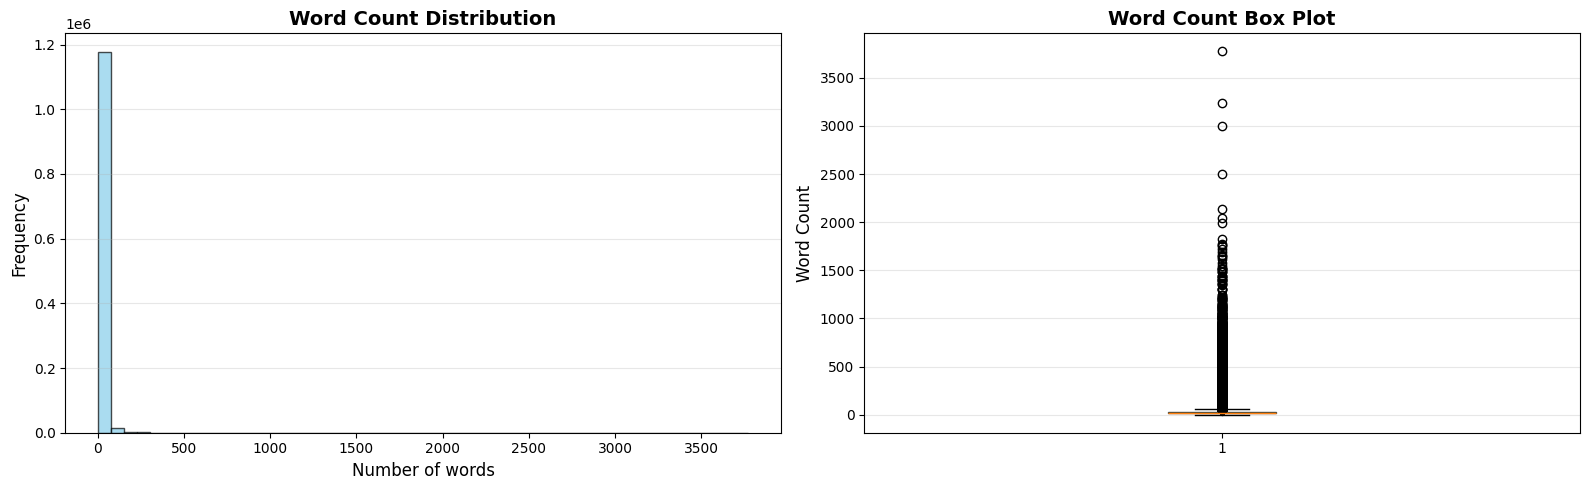


Short sentences (less than 5 words):
  1. هذه هي المسالة الرئيسية.
  2. 6).
  3. 167/L.

Medium sentences (10-15 words):
  1. ومطالبة وحدة الرسائل بالقيام بانواع اخرى من العمل يبدد موارد اللجنة.
  2. وسداد مثل هذه التكاليف غالبا ما يجري باقتطاع نسبة مئوية ثابتة من الاشتراكات.
  3. ١- حققت جمهورية كرواتيا استقلالها في عام ١٩٩١، ونالت الاعتراف الدولي الكامل في مطلع ١٩٩٢.

Long sentences (more than 30 words):
  1. ٢-٢ ويسعى صاحب البلاغ منذ عام ١٨٩١، دونما نجاح، الى الحصول على مساعدة قانونية بغية تقديم التماس للحصول على اذن بالاستئناف امام اللجنة القضائية التابعة لمجلس الملكة، فقد هاجر ممثله الاول السيد الكوت من جامايكا، ورفضت ابنته، وهي ايضا محامية، تولي القضية لانها لم تر طائلا من ورائها.
  2. ١٣ - وفي الساعة ٢٠/٢٠ من يوم ١٠ ايار/مايو ١٩٩٣، عبر ١٣ شخصا معادين للثورة الحدود الدولية عند الاحداثين الجغرافيين ٢٤٠٠ - ٩٤٦٠٠ على خارطة نهر ميمه معتزمين دخول اراضي جمهورية ايران الاسلامية، الا انهم لاذوا بالفرار عندما تصدت لهم القوات الايرانية.
  3. 8( لتحديد ما اذا كان اُذن لمن حضروا الحلقات الد

In [ ]:


print(f"\nSentences with 1-10 words: {(df['word_count'] <= 10).sum() / len(df) * 100:.2f}%")
print(f"Sentences with 11-20 words: {((df['word_count'] > 10) & (df['word_count'] <= 20)).sum() / len(df) * 100:.2f}%")
print(f"Sentences with 21-30 words: {((df['word_count'] > 20) & (df['word_count'] <= 30)).sum() / len(df) * 100:.2f}%")
print(f"Sentences with more than 30 words: {(df['word_count'] > 30).sum() / len(df) * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(df['word_count'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of words', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Box Plot
axes[1].boxplot(df['word_count'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[1].set_ylabel('Word Count', fontsize=12)
axes[1].set_title('Word Count Box Plot', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nShort sentences (less than 5 words):")
for i, s in enumerate(df[df['word_count'] < 5]['Sentence'].sample(min(3, len(df[df['word_count'] < 5])), random_state=42), 1):
    print(f"  {i}. {s}")

print("\nMedium sentences (10-15 words):")
for i, s in enumerate(df[(df['word_count'] >= 10) & (df['word_count'] <= 15)]['Sentence'].sample(min(3, len(df[(df['word_count'] >= 10) & (df['word_count'] <= 15)])), random_state=42), 1):
    print(f"  {i}. {s}")

print("\nLong sentences (more than 30 words):")
for i, s in enumerate(df[df['word_count'] > 30]['Sentence'].sample(min(3, len(df[df['word_count'] > 30])), random_state=42), 1):
    print(f"  {i}. {s}")


## 2.4 Punctuation Marks Analysis

<div dir="rtl" >
<h4 >
إحصاء عدد علامات الترقيم في البيانات المتسخدمة
<br>
<h4>
نلاحظ أن عدد علامات التعجب صغير جدا مقارنة بالنقاط والفواصل
و أيضا عدد علامات الاستفهام صغير نسبيا</h4>
</h4>
</div>

In [ ]:

punctuation_marks = {
    'question_mark': '؟',
    'colon': ':',
    'comma': '،',
    'semicolon': '؛',
    'exclamation': '!',
    'full_stop': '.'
}

punct_names = {
    'question_mark': 'Question Mark (?)',
    'colon': 'Colon (:)',
    'comma': 'Comma (،)',
    'semicolon': 'Semicolon (؛)',
    'exclamation': 'Exclamation (!)',
    'full_stop': 'Full Stop (.)'
}

punct_stats = {}
for key, mark in punctuation_marks.items():
    total = df['Sentence'].str.count(re.escape(mark)).sum()
    sentences = (df['Sentence'].str.contains(re.escape(mark), regex=True)).sum()
    percentage = (sentences / len(df)) * 100

    punct_stats[key] = {
        'total': total,
        'sentences': sentences,
        'percentage': percentage
    }

print("\nPunctuation statistics:\n")
for key, stats in punct_stats.items():
    print(f"{punct_names[key]}")
    print(f"  Total occurrences: {stats['total']:,}")
    print(f"  Sentences containing it: {stats['sentences']:,} ({stats['percentage']:.2f}%)")

total_punct = sum([s['total'] for s in punct_stats.values()])
print(f"\nTotal punctuation marks: {total_punct:,}")
print(f"Average per sentence: {total_punct / len(df):.2f}")




Punctuation statistics:

Question Mark (?)
  Total occurrences: 5,800
  Sentences containing it: 5,124 (0.43%)
Colon (:)
  Total occurrences: 61,940
  Sentences containing it: 57,285 (4.79%)
Comma (،)
  Total occurrences: 1,521,575
  Sentences containing it: 640,577 (53.61%)
Semicolon (؛)
  Total occurrences: 143,921
  Sentences containing it: 54,299 (4.54%)
Exclamation (!)
  Total occurrences: 90
  Sentences containing it: 83 (0.01%)
Full Stop (.)
  Total occurrences: 1,192,367
  Sentences containing it: 1,192,366 (99.80%)

Total punctuation marks: 2,925,693
Average per sentence: 2.45


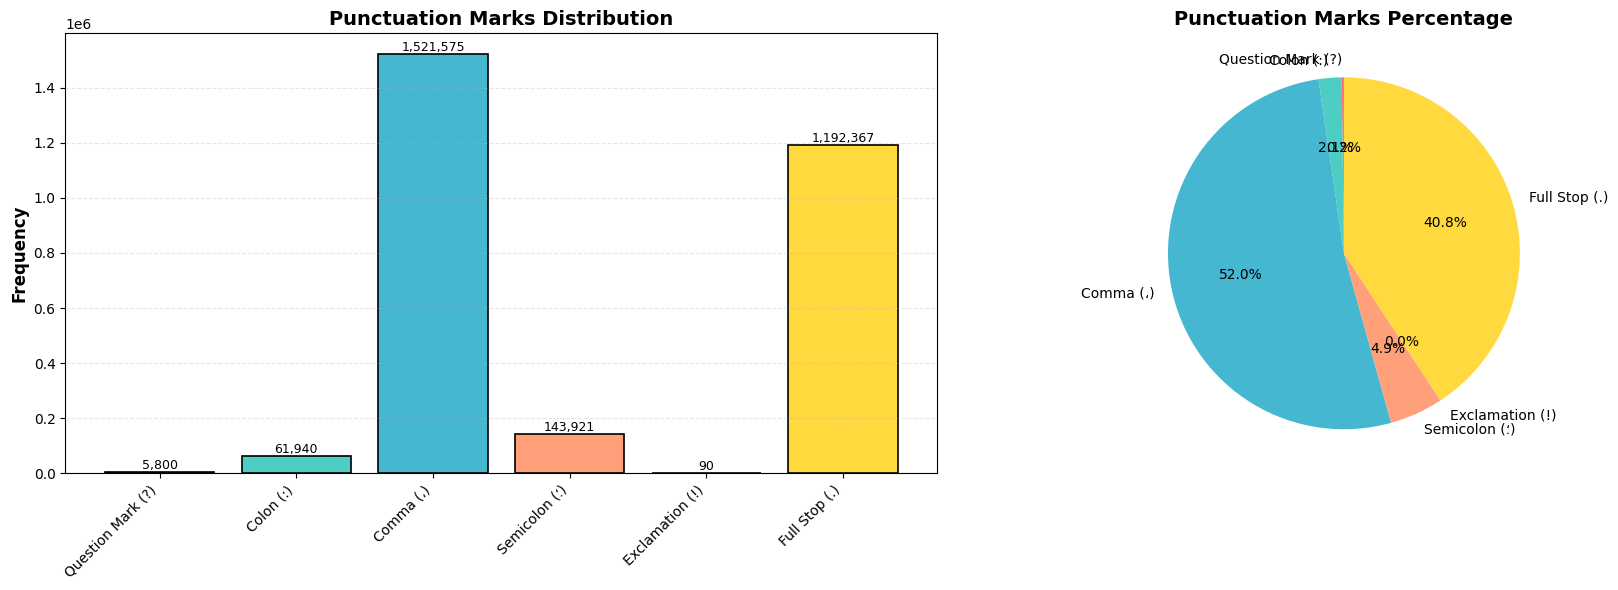


Class Balance Analysis:
  Most frequent: Comma (،) (1,521,575)
  Least frequent: Exclamation (!) (90)
  Imbalance ratio: 16906.39:1



In [ ]:
names = [punct_names[k] for k in punct_stats.keys()]
counts = [punct_stats[k]['total'] for k in punct_stats.keys()]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar Chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#FFD93D']
bars = axes[0].bar(range(len(names)), counts, color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=45, ha='right', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Punctuation Marks Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for i, count in enumerate(counts):
    axes[0].text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

# Pie Chart
axes[1].pie(counts, labels=names, autopct='%1.1f%%', colors=colors,
           startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Punctuation Marks Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

max_count = max(counts)
min_count = min(counts)
imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

print("\nClass Balance Analysis:")
print(f"  Most frequent: {names[counts.index(max_count)]} ({max_count:,})")
print(f"  Least frequent: {names[counts.index(min_count)]} ({min_count:,})")
print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 10:
    print("\n  Warning: Significant class imbalance detected!")
elif imbalance_ratio > 5:
    print("\n  Note: Moderate class imbalance. Monitor performance on minority classes.")
else:
    print("\n  Note: Relatively balanced distribution.")


## 2.5 Punctuation Density Analysis

<div dir="rtl" >
<h4 >
حساب متوسط عدد علامات الترقيم في كل جملة ومتوسط المسافة بين كل علامة وأخرى
</h4>
</div>


Punctuation per sentence:
  Mean: 2.45
  Median: 2
  Min: 1
  Max: 253

Average words between punctuation marks: 7.90


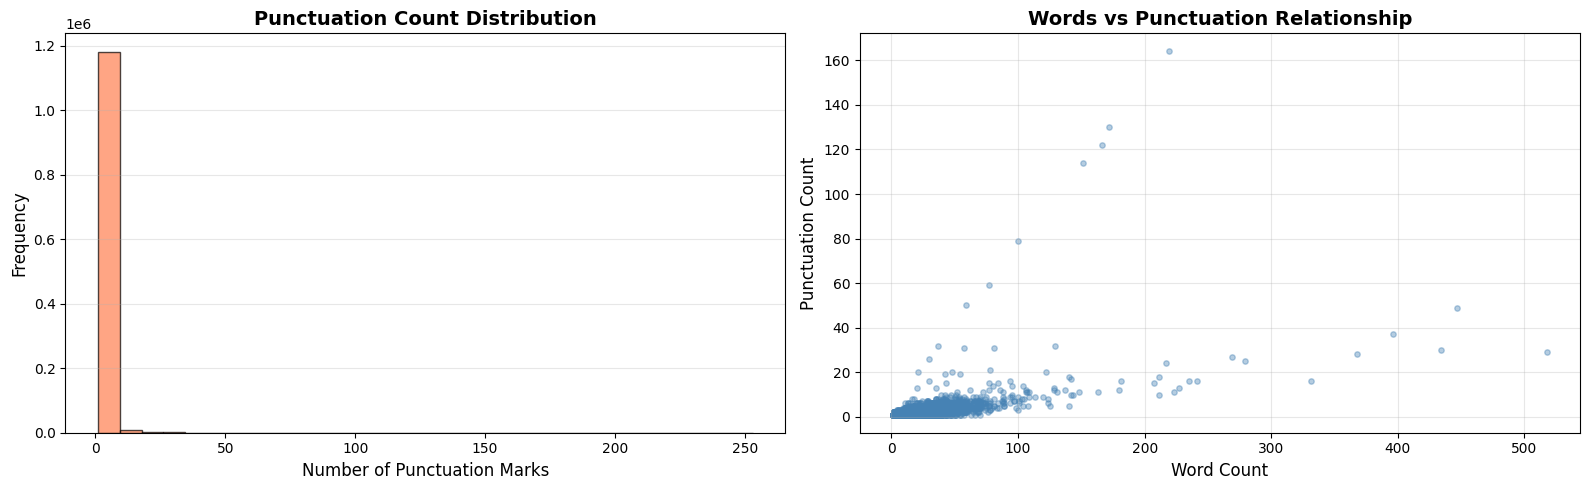

8611

In [ ]:

all_marks_pattern = '|'.join([re.escape(m) for m in punctuation_marks.values()])
df['punct_count'] = df['Sentence'].str.count(all_marks_pattern)

print(f"\nPunctuation per sentence:")
print(f"  Mean: {df['punct_count'].mean():.2f}")
print(f"  Median: {df['punct_count'].median():.0f}")
print(f"  Min: {df['punct_count'].min()}")
print(f"  Max: {df['punct_count'].max()}")

df_with_punct = df[df['punct_count'] > 0]
avg_distance = (df_with_punct['word_count'] / (df_with_punct['punct_count'] + 1)).mean()
print(f"\nAverage words between punctuation marks: {avg_distance:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df['punct_count'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Punctuation Marks', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Punctuation Count Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

sample = df.sample(min(5000, len(df)), random_state=42)
axes[1].scatter(sample['word_count'], sample['punct_count'],
               alpha=0.4, color='steelblue', s=15)
axes[1].set_xlabel('Word Count', fontsize=12)
axes[1].set_ylabel('Punctuation Count', fontsize=12)
axes[1].set_title('Words vs Punctuation Relationship', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

import gc
gc.collect()




<div dir="rtl" >
<h4 >
اكتشفنا من هذه الإحصائيات أن الداتاسيت غير متوازنة لهكذا سنقوم بتطبيق ال sampling في بعض النماذج لتحسين الدقة</h4>
</div>

# data sampling

## 3.1  Sampling Configuration

<div dir="rtl" >
<h4 >
تحديد العدد المطلوب من كل علامة ترقيم
<br>
تم اختيار الارقام بناءا على نسبة عدد علامة التعجب بالنسبة لغيرها
</h4>
</div>

In [ ]:
RANDOM_STATE = 42
rng = random.Random(RANDOM_STATE)

TARGET_SENT_COUNTS = {
    '؟': 8000,
    '!': 690,
    '؛': 7000,
    ':': 7000,
    '،': 5000,
    '.': 5000
}
NEUTRAL_TARGET = 8000
PUNCTS = list(TARGET_SENT_COUNTS.keys())

print("\nTarget sentence counts per punctuation type:")
print(f"  Question mark (؟): {TARGET_SENT_COUNTS['؟']:,}")
print(f"  Exclamation (!): {TARGET_SENT_COUNTS['!']:,}")
print(f"  Semicolon (؛): {TARGET_SENT_COUNTS['؛']:,}")
print(f"  Colon (:): {TARGET_SENT_COUNTS[':']:,}")
print(f"  Comma (،): {TARGET_SENT_COUNTS['،']:,}")
print(f"  Full stop (.): {TARGET_SENT_COUNTS['.']:,}")
print(f"  Neutral (no punctuation): {NEUTRAL_TARGET:,}")
print(f"\nTotal target sentences: {sum(TARGET_SENT_COUNTS.values()) + NEUTRAL_TARGET:,}")


Target sentence counts per punctuation type:
  Question mark (؟): 8,000
  Exclamation (!): 690
  Semicolon (؛): 7,000
  Colon (:): 7,000
  Comma (،): 5,000
  Full stop (.): 5,000
  Neutral (no punctuation): 8,000

Total target sentences: 40,690


## 3.2 Helper Functions

<div dir="rtl" >
<h4 >
بعض الدوال المفيدة في عملية ال sampling
<br>
- normalize_sentence من اجل توحيد العلامات والارقام وحذف تكرار العلامات المتسلسل وحذف الفراغات المتسلسلة
<br>
- iter_sentences_from_files للمرور على كل ملف ومعالجة الجمل داخله
<br>
- all_buckets_full تابع التوقف أي عندما نتحقق من وصولنا للهدف وهو عدد العلامات المطلوب
</h4>
</div>

In [ ]:

NUMBERING_RE = re.compile(r'^\s*[0-9٠-٩]+\s*\.\s*')
WRAPPERS_RE = re.compile(r'[«»"""\(\)\[\]\{\}]')

def normalize_sentence(s: str) -> str:
    """
    Normalize sentence by:
    - Removing leading numbering
    - Replacing ASCII punctuation with Arabic equivalents
    - Removing duplicate punctuation
    - Normalizing whitespace
    """
    s = str(s)
    s = NUMBERING_RE.sub('', s)
    s = s.replace(',', '،').replace('?', '؟').replace(';', '؛')
    s = re.sub(r'([!.؟،؛:])\1+', r'\1', s)  # Remove duplicates
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def iter_sentences_from_files(folder: str):
    """Generator to iterate through all txt files in folder"""
    file_list = sorted([f for f in os.listdir(folder) if f.endswith('.txt')])
    print(f"\nFound {len(file_list):,} txt files in dataset")

    for idx, fn in enumerate(file_list, 1):
        fp = os.path.join(folder, fn)
        with open(fp, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                line = line.strip()
                if line:
                    yield line

        if idx % 10 == 0 or idx == len(file_list):
            print(f"  Processed {idx}/{len(file_list)} files")

def all_buckets_full(buckets, neutral):
    """Check if all sampling targets have been reached"""
    return (all(len(buckets[p]) >= TARGET_SENT_COUNTS[p] for p in PUNCTS)
            and len(neutral) >= NEUTRAL_TARGET)

print("Helper functions defined successfully")

Helper functions defined successfully


## 3.3 Sampling Process

In [ ]:
buckets = {p: [] for p in PUNCTS}
neutral = []
neutral_seen_total = 0  # For correct reservoir sampling
seen = set()

n_read = 0
n_duplicates = 0
n_empty = 0

print("\nStarting sentence sampling...\n")

for raw in iter_sentences_from_files(DATA_FOLDER):
    n_read += 1
    s = normalize_sentence(raw)

    if not s:
        n_empty += 1
        continue

    if s in seen:
        n_duplicates += 1
        continue

    present = [p for p in PUNCTS if p in s]

    if present:
        candidates = [p for p in present if len(buckets[p]) < TARGET_SENT_COUNTS[p]]
        if candidates:
            # Choose bucket with lowest fill ratio
            p_chosen = min(candidates, key=lambda p: len(buckets[p]) / TARGET_SENT_COUNTS[p])
            buckets[p_chosen].append(s)
            seen.add(s)
    else:
        neutral_seen_total += 1
        if len(neutral) < NEUTRAL_TARGET:
            neutral.append(s)
            seen.add(s)
        else:
            j = rng.randrange(neutral_seen_total)
            if j < NEUTRAL_TARGET:
                old_sentence = neutral[j]
                neutral[j] = s
                seen.discard(old_sentence)
                seen.add(s)

    if n_read % 1_000_000 == 0:
        print(f"Lines read: {n_read:,}")
        print(f"  Question: {len(buckets['؟']):,} / {TARGET_SENT_COUNTS['؟']:,}")
        print(f"  Exclamation: {len(buckets['!'])} / {TARGET_SENT_COUNTS['!']}")
        print(f"  Semicolon: {len(buckets['؛']):,} / {TARGET_SENT_COUNTS['؛']:,}")
        print(f"  Colon: {len(buckets[':'])} / {TARGET_SENT_COUNTS[':']}")
        print(f"  Comma: {len(buckets['،']):,} / {TARGET_SENT_COUNTS['،']:,}")
        print(f"  Full stop: {len(buckets['.'])} / {TARGET_SENT_COUNTS['.']}")
        print(f"  Neutral: {len(neutral):,} / {NEUTRAL_TARGET:,}")
        print()

    if all_buckets_full(buckets, neutral):
        print("All sampling targets reached!")
        break

print("\n" + "=" * 70)
print("SAMPLING COMPLETE".center(70))
print("=" * 70)
print(f"\nTotal lines processed: {n_read:,}")
print(f"Empty lines skipped: {n_empty:,}")
print(f"Duplicate sentences skipped: {n_duplicates:,}")
print(f"Unique sentences kept: {len(seen):,}")


Starting sentence sampling...


Found 79 txt files in dataset
Lines read: 1,000,000
  Question: 4,558 / 8,000
  Exclamation: 89 / 690
  Semicolon: 7,000 / 7,000
  Colon: 7000 / 7000
  Comma: 5,000 / 5,000
  Full stop: 5000 / 5000
  Neutral: 0 / 8,000

  Processed 10/79 files
Lines read: 2,000,000
  Question: 8,000 / 8,000
  Exclamation: 171 / 690
  Semicolon: 7,000 / 7,000
  Colon: 7000 / 7000
  Comma: 5,000 / 5,000
  Full stop: 5000 / 5000
  Neutral: 0 / 8,000

Lines read: 3,000,000
  Question: 8,000 / 8,000
  Exclamation: 236 / 690
  Semicolon: 7,000 / 7,000
  Colon: 7000 / 7000
  Comma: 5,000 / 5,000
  Full stop: 5000 / 5000
  Neutral: 0 / 8,000

  Processed 20/79 files
Lines read: 4,000,000
  Question: 8,000 / 8,000
  Exclamation: 284 / 690
  Semicolon: 7,000 / 7,000
  Colon: 7000 / 7000
  Comma: 5,000 / 5,000
  Full stop: 5000 / 5000
  Neutral: 0 / 8,000

  Processed 30/79 files
Lines read: 5,000,000
  Question: 8,000 / 8,000
  Exclamation: 337 / 690
  Semicolon: 7,000 / 7,000
  

## 3.4 Create DataFrame

<div dir="rtl" >
<h4 >
تجهيز ال DataFrame</h4>
</div>

In [ ]:
# Build rows for DataFrame
rows = []
for p, sents in buckets.items():
    for sentence in sents:
        rows.append({"Sentence": sentence, "punct": p})

for sentence in neutral:
    rows.append({"Sentence": sentence, "punct": "0"})

# Create DataFrame and shuffle
df_sampled = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"\nTotal sampled sentences: {len(df_sampled):,}")
print("\nSentence-level distribution:")
counts = df_sampled["punct"].value_counts().sort_index()
print(f"  Neutral (0): {counts.get('0', 0):,}")
print(f"  Exclamation (!): {counts.get('!', 0)}")
print(f"  Full stop (.): {counts.get('.', 0):,}")
print(f"  Colon (:): {counts.get(':', 0):,}")
print(f"  Comma (،): {counts.get('،', 0):,}")
print(f"  Semicolon (؛): {counts.get('؛', 0):,}")
print(f"  Question (؟): {counts.get('؟', 0):,}")


Total sampled sentences: 32,690

Sentence-level distribution:
  Neutral (0): 0
  Exclamation (!): 690
  Full stop (.): 5,000
  Colon (:): 7,000
  Comma (،): 5,000
  Semicolon (؛): 7,000
  Question (؟): 8,000


## 3.5 Label Encoding Setup

<div dir="rtl" >
<h4 >
تعريف بنية الخرج </h4>
</div>

In [ ]:
label_to_punctuation = {
    0: '<PAD>',
    1: 'O',
    2: '؟',
    3: ':',
    4: '،',
    5: '؛',
    7: '.'
}

punctuation_to_label = {v: k for k, v in label_to_punctuation.items()}

PAD_LABEL = 0
O_LABEL = 1
PUNCT_SET = {'؟', '!', '؛', ':', '،', '.'}

PUNCT_PRIORITY = {
    '؟': 6,
    '!': 5,
    '.': 4,
    '؛': 3,
    ':': 2,
    '،': 1
}

print("\nLabel encoding mapping:")
for label_id, punct_symbol in label_to_punctuation.items():
    print(f"  Label {label_id}: {punct_symbol}")

print("\nPunctuation priority (for multiple marks on same word):")
for punct, priority in sorted(PUNCT_PRIORITY.items(), key=lambda x: x[1], reverse=True):
    print(f"  {punct}: priority {priority}")


Label encoding mapping:
  Label 0: <PAD>
  Label 1: O
  Label 2: ؟
  Label 3: :
  Label 4: ،
  Label 5: ؛
  Label 7: .

Punctuation priority (for multiple marks on same word):
  ؟: priority 6
  !: priority 5
  .: priority 4
  ؛: priority 3
  :: priority 2
  ،: priority 1


## 3.6 Token Extraction Function

In [ ]:
def extract_words_and_labels(sentence: str):
    """
    Extract words and assign punctuation labels

    Process:
    1. Remove wrapper characters (quotes, parentheses)
    2. Isolate punctuation marks with spaces
    3. Split into tokens
    4. Assign punctuation labels to preceding words
    5. Handle multiple punctuation marks by priority

    Returns:
        words: list of word tokens
        labels: list of label IDs (same length as words)
    """
    s = str(sentence)
    s = WRAPPERS_RE.sub(' ', s)
    s = re.sub(r'([؟!؛:،.])', r' \1 ', s)
    s = re.sub(r'\s+', ' ', s).strip()

    tokens = s.split()
    words = []
    labels = []

    for tok in tokens:
        if tok in PUNCT_SET:
            if labels:
                new_lab = punctuation_to_label[tok]
                cur_lab = labels[-1]

                if cur_lab == O_LABEL:
                    # No punctuation assigned yet, assign this one
                    labels[-1] = new_lab
                else:
                    cur_sym = label_to_punctuation[cur_lab]
                    if PUNCT_PRIORITY.get(tok, 0) > PUNCT_PRIORITY.get(cur_sym, 0):
                        labels[-1] = new_lab
            continue

        words.append(tok)
        labels.append(O_LABEL)

    return words, labels

print("Token extraction function defined")
print("\nFunction will:")
print("  - Extract word tokens from sentences")
print("  - Assign punctuation labels to words")
print("  - Handle multiple punctuation marks by priority")
print("  - Return aligned word and label lists")

Token extraction function defined

Function will:
  - Extract word tokens from sentences
  - Assign punctuation labels to words
  - Handle multiple punctuation marks by priority
  - Return aligned word and label lists


## 3.7 Build Token Sequences

In [ ]:
all_sequences = []
all_labels = []
n_empty = 0

print("\nExtracting tokens and labels from sentences...\n")

for i, sentence in enumerate(df_sampled['Sentence'], 1):
    words, labels = extract_words_and_labels(sentence)

    if words:
        all_sequences.append(words)
        all_labels.append(labels)
    else:
        n_empty += 1

    if i % 5000 == 0:
        print(f"  Processed {i:,} / {len(df_sampled):,} sentences")

sequence_lengths = [len(seq) for seq in all_sequences]

print(f"\nTotal valid sequences: {len(all_sequences):,}")
print(f"Empty sequences (no tokens): {n_empty}")

# Verify alignment
alignment_ok = all(len(words) == len(labels)
                   for words, labels in zip(all_sequences, all_labels))
print(f"Word-label alignment verified: {alignment_ok}")

In [ ]:
print(df_sampled.columns)


Index(['Sentence', 'punct'], dtype='object')


## 3.8 Create Training Data Dictionary

In [ ]:
training_data = {
    "sequences": all_sequences,
    "labels": all_labels,
    "sequence_lengths": sequence_lengths,
    "label_to_punctuation": label_to_punctuation,
    "punctuation_to_label": punctuation_to_label,
    "PAD_LABEL": PAD_LABEL,
    "O_LABEL": O_LABEL,
    "df_sampled": df_sampled,
}

print("\nTraining data dictionary created with keys:")
for key in training_data.keys():
    if key == "sequences":
        print(f"  - {key}: {len(training_data[key]):,} sequences")
    elif key == "labels":
        print(f"  - {key}: {len(training_data[key]):,} label sequences")
    elif key == "sequence_lengths":
        print(f"  - {key}: {len(training_data[key]):,} length values")
    elif key == "df_sampled":
        print(f"  - {key}: DataFrame with {len(training_data[key]):,} rows")
    else:
        print(f"  - {key}")


Training data dictionary created with keys:
  - sequences: 32,687 sequences
  - labels: 32,687 label sequences
  - sequence_lengths: 32,687 length values
  - label_to_punctuation
  - punctuation_to_label
  - PAD_LABEL
  - O_LABEL
  - df_sampled: DataFrame with 32,690 rows


## 3.9 Final Statistics & Summary

In [ ]:
# Sentence-level distribution
print("\n1. SENTENCE-LEVEL DISTRIBUTION")
print("-" * 70)
sent_counts = df_sampled["punct"].value_counts().sort_index()
print(f"Neutral sentences (0): {sent_counts.get('0', 0):,}")
print(f"Exclamation sentences (!): {sent_counts.get('!', 0)}")
print(f"Full stop sentences (.): {sent_counts.get('.', 0):,}")
print(f"Colon sentences (:): {sent_counts.get(':', 0):,}")
print(f"Comma sentences (،): {sent_counts.get('،', 0):,}")
print(f"Semicolon sentences (؛): {sent_counts.get('؛', 0):,}")
print(f"Question sentences (؟): {sent_counts.get('؟', 0):,}")

# Token-level label distribution
print("\n2. TOKEN-LEVEL LABEL DISTRIBUTION")
print("-" * 70)
label_counts = Counter(label for seq in all_labels for label in seq)
total_tokens = sum(label_counts.values())

print(f"Total tokens: {total_tokens:,}\n")
for label_id in sorted(label_counts.keys()):
    punct_symbol = label_to_punctuation[label_id]
    count = label_counts[label_id]
    percentage = (count / total_tokens) * 100

    if label_id == O_LABEL:
        print(f"Label {label_id} (O - No punctuation): {count:,} ({percentage:.2f}%)")
    else:
        print(f"Label {label_id} ({punct_symbol}): {count:,} ({percentage:.2f}%)")

# Sequence length statistics
print("\n3. SEQUENCE LENGTH STATISTICS")
print("-" * 70)
print(f"Mean length: {np.mean(sequence_lengths):.2f} tokens")
print(f"Median length: {np.median(sequence_lengths):.0f} tokens")
print(f"Min length: {min(sequence_lengths)} tokens")
print(f"Max length: {max(sequence_lengths)} tokens")
print(f"Std deviation: {np.std(sequence_lengths):.2f} tokens")

# Length distribution percentiles
print("\nLength percentiles:")
print(f"  25th percentile: {np.percentile(sequence_lengths, 25):.0f} tokens")
print(f"  50th percentile: {np.percentile(sequence_lengths, 50):.0f} tokens")
print(f"  75th percentile: {np.percentile(sequence_lengths, 75):.0f} tokens")
print(f"  90th percentile: {np.percentile(sequence_lengths, 90):.0f} tokens")
print(f"  95th percentile: {np.percentile(sequence_lengths, 95):.0f} tokens")



1. SENTENCE-LEVEL DISTRIBUTION
----------------------------------------------------------------------
Neutral sentences (0): 0
Exclamation sentences (!): 690
Full stop sentences (.): 5,000
Colon sentences (:): 7,000
Comma sentences (،): 5,000
Semicolon sentences (؛): 7,000
Question sentences (؟): 8,000

2. TOKEN-LEVEL LABEL DISTRIBUTION
----------------------------------------------------------------------


NameError: name 'Counter' is not defined

# dictionary

في هذه الخلية قمنا بتجهيز فهرس منظم لتجميع ومتابعة نتائج تجارب النماذج المختلفة

بعد ذلك قمنا بتعريف بنية فهرس Index على شكل قاموس يحتوي على معلومات كل تجربة مثل رقم الخطوة اسم النموذج الميزات المستخدمة اعدادات النموذج طرق المعالجة المسبقة بالاضافة الى مقاييس التقييم مثل الدقة Accuracy و F score

تم انشاء دوال مساعدة لاضافة نتائج كل تجربة الى هذا الفهرس وتحويله لاحقا الى DataFrame لسهولة العرض والتحليل مع دالة خاصة لطباعة جدول مقارنة بين النماذج مرتب حسب الاداء

اخيرا نقوم بمحاولة تحميل الفهرس المحفوظ مسبقا من Google Drive في حال كان موجودا وذلك لضمان عدم فقدان نتائج التجارب السابقة وفي حال عدم وجوده يتم انشاء فهرس جديد للبدء من الصفر

In [ ]:
import os
import pickle
import pandas as pd

def init_results_index():
    return {"number_step": [], "name_model": [], "features": [],
            "parameters_model": [], "methods_preprocessing": [],
            "accuracy": [], "F-score": []}

def append_result(index_dict, *, number_step, name_model, features,
                  parameters_model, methods_preprocessing, accuracy, f_score):
    index_dict["number_step"].append(number_step)
    index_dict["name_model"].append(name_model)
    index_dict["features"].append(features)
    index_dict["parameters_model"].append(parameters_model)
    index_dict["methods_preprocessing"].append(methods_preprocessing)
    index_dict["accuracy"].append(float(accuracy))
    index_dict["F-score"].append(float(f_score))

def index_to_df(index_dict):
    return pd.DataFrame(index_dict)


def print_models_comparison_table(index_dict, sort_by="F-score"):
    df = index_to_df(index_dict).copy()
    if len(df) == 0:
        print("\n[WARN] No rows to print.")
        return df
    df = df.sort_values(by=[sort_by, "accuracy"], ascending=False)
    print("\n" + "="*80)
    print("MODELS COMPARISON TABLE".center(80))
    print("="*80)
    print(df.to_string(index=False))
    return df


RESULTS_PATH = '/content/drive/MyDrive/models/results_all_models.pkl'
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, 'rb') as f:
        results_all_models = pickle.load(f)
    print(f" الفهرس محمّل ({len(results_all_models['name_model'])} نماذج)")
else:
    results_all_models = init_results_index()
    print("new index")

results_best_per_request = init_results_index()

new index


في هذه الخلية قمنا بتعريف دالة مسؤولة عن اختيار افضل نموذج لكل طلب تدريب محدد
تعتمد الدالة على فلتر يتم تمريره لتحديد الصفوف التي تنتمي لنفس الطلب او التجربة

يتم اولا تحويل فهرس جميع النتائج الى DataFrame ثم تصفية النتائج حسب الفلتر المعطى
بعد ذلك يتم اختيار افضل نتيجة اعتمادا على مقياس F score

في حال تم العثور على نتيجة مناسبة يتم حفظ معلومات هذا النموذج الافضل في فهرس خاص يحتوي فقط على افضل نموذج لكل طلب
الهدف من هذه العملية هو تسهيل مقارنة النتائج النهائية دون تكرار النماذج او الخلط بين التجارب المختلفة

In [ ]:
def finalize_best_for_request(results_all_models, request_filter_fn):

    df_all = index_to_df(results_all_models)
    df_req = df_all[df_all.apply(request_filter_fn, axis=1)].copy()

    best = select_best_row_from_df(df_req, prefer="F-score")
    if best is None:
        return

    append_result(
        results_best_per_request,
        number_step=best["number_step"],
        name_model=best["name_model"],
        features=best["features"],
        parameters_model=best["parameters_model"],
        methods_preprocessing=best["methods_preprocessing"],
        accuracy=best["accuracy"],
        f_score=best["F-score"],
    )

# embedding models

## 1)- intern embedding

### Model 1: BiLSTM (PyTorch)

<div dir="rtl" >
<h4 >

في هذه الخلية قمنا ببناء وتدريب نموذج BiLSTM باستخدام PyTorch لمهمة ترقيم النصوص
تبدأ العملية ببناء قاموس الكلمات اعتمادا على بيانات التدريب ثم تقسيم البيانات الى تدريب تحقق واختبار

بعد ذلك يتم تعريف Dataset و DataLoader للتعامل مع الجمل ذات الاطوال المختلفة مع تطبيق الحشو
ثم قمنا بتعريف نموذج BiLSTM ثنائي الاتجاه مع طبقة تضمين وطبقة اخراج لتوقع الفئات

تم حساب اوزان الفئات لمعالجة عدم توازن البيانات واستخدامها داخل دالة الخطأ
بعدها يتم تدريب النموذج عبر عدة عصور مع مراقبة اداء مجموعة التحقق وتطبيق الايقاف المبكر

في النهاية يتم تقييم النموذج على بيانات الاختبار وحساب مقاييس الاداء وحفظ النموذج والاعدادات
واخيرا يتم تسجيل نتائج هذا النموذج داخل فهرس النتائج لاستخدامها في المقارنة مع النماذج الاخرى
</h4>
</div>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
from collections import Counter
import numpy as np
import pickle

print("\n" + "="*70)
print("BiLSTM MODEL TRAINING (PyTorch)".center(70))
print("="*70)

# Build Vocabulary
def build_vocab(sequences, min_freq=2):
    counter = Counter(word for seq in sequences for word in seq)
    vocab = {'<PAD>': 0, '<UNK>': 1}
    idx = 2
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1
    return vocab

vocab = build_vocab(all_sequences, min_freq=2)
VOCAB_SIZE = len(vocab)
NUM_CLASSES = len(label_to_punctuation)

print(f"\nVocabulary size: {VOCAB_SIZE:,}")
print(f"Number of classes: {NUM_CLASSES}")

# Dataset & DataLoader
class PunctuationDataset(Dataset):
    def __init__(self, sequences, labels, vocab, max_len=128):
        self.sequences = sequences
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        words = self.sequences[idx][:self.max_len]
        labs = self.labels[idx][:self.max_len]
        word_ids = [self.vocab.get(w, self.vocab['<UNK>']) for w in words]
        return torch.tensor(word_ids, dtype=torch.long), torch.tensor(labs, dtype=torch.long)

def collate_fn(batch):
    sequences, labels = zip(*batch)
    seq_lens = torch.tensor([len(s) for s in sequences])
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0)
    padded_labs = pad_sequence(labels, batch_first=True, padding_value=PAD_LABEL)
    return padded_seqs, padded_labs, seq_lens

X_train, X_temp, y_train, y_temp = train_test_split(
    all_sequences, all_labels, test_size=0.2, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

print(f"\nData split → Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

BATCH_SIZE = 32
MAX_LEN = 128

train_dataset = PunctuationDataset(X_train, y_train, vocab, MAX_LEN)
val_dataset = PunctuationDataset(X_val, y_val, vocab, MAX_LEN)
test_dataset = PunctuationDataset(X_test, y_test, vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Model Definition
class BiLSTM_Punctuation(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=256, num_classes=8,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths=None):
        embedded = self.dropout(self.embedding(x))
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            rnn_out, _ = self.rnn(packed)
            rnn_out, _ = nn.utils.rnn.pad_packed_sequence(rnn_out, batch_first=True)
        else:
            rnn_out, _ = self.rnn(embedded)
        return self.fc(self.dropout(rnn_out))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

torch_model = BiLSTM_Punctuation(
    vocab_size=VOCAB_SIZE, embed_dim=256, hidden_dim=256,
    num_classes=NUM_CLASSES, num_layers=2, dropout=0.3
).to(device)


# Loss & Optimizer
flat_labels = [l for seq in all_labels for l in seq]
class_counts = Counter(flat_labels)
total = sum(class_counts.values())

class_weights = [total / (NUM_CLASSES * class_counts.get(i, 1)) for i in range(NUM_CLASSES)]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
class_weights[PAD_LABEL] = 0.0

print("\nClass weights:")
for i, w in enumerate(class_weights):
    print(f"  {label_to_punctuation[i]}: {w:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=PAD_LABEL)
optimizer = torch.optim.AdamW(torch_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=2)

# Training Functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_correct = 0
    total_tokens = 0

    for seqs, labels, lengths in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()

        logits = model(seqs, lengths)
        loss = criterion(logits.view(-1, NUM_CLASSES), labels.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        mask = labels != PAD_LABEL
        total_correct += (preds[mask] == labels[mask]).sum().item()
        total_tokens += mask.sum().item()

    return total_loss / len(loader), total_correct / total_tokens

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_true = [], []

    with torch.no_grad():
        for seqs, labels, lengths in loader:
            seqs, labels = seqs.to(device), labels.to(device)
            logits = model(seqs, lengths)
            loss = criterion(logits.view(-1, NUM_CLASSES), labels.view(-1))
            total_loss += loss.item()

            preds = logits.argmax(dim=-1)
            for i in range(len(lengths)):
                length = lengths[i].item()
                all_preds.extend(preds[i, :length].cpu().tolist())
                all_true.extend(labels[i, :length].cpu().tolist())

    accuracy = sum(p == t for p, t in zip(all_preds, all_true)) / len(all_preds)
    return total_loss / len(loader), accuracy, all_preds, all_true

# Training
NUM_EPOCHS = 15
best_val_loss = float('inf')
patience_counter = 0
EARLY_STOP_PATIENCE = 5

print("\n" + "="*70)
print("Training started...".center(70))
print("="*70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(torch_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(torch_model, val_loader, criterion, device)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(torch_model.state_dict(), 'best_bilstm_punct.pt')
        print("  ✓ Best model saved")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

#
#  Test
torch_model.load_state_dict(torch.load('best_bilstm_punct.pt'))
test_loss, test_acc, test_preds, test_true = evaluate(torch_model, test_loader, criterion, device)

print("\n" + "="*70)
print("TEST RESULTS".center(70))
print("="*70)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

filtered_true = [t for t in test_true if t != PAD_LABEL]
filtered_pred = [p for t, p in zip(test_true, test_preds) if t != PAD_LABEL]

unique_labels_no_pad = sorted(set(filtered_true))
precision, recall, f1, support = precision_recall_fscore_support(
    filtered_true, filtered_pred, labels=unique_labels_no_pad, zero_division=0
)

weighted_f1 = np.average(f1, weights=support)

print(f"\nMacro F1: {f1.mean():.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

# Save Config
with open('bilstm_config.pkl', 'wb') as f:
    pickle.dump({
        'vocab': vocab,
        'label_to_punctuation': label_to_punctuation,
        'vocab_size': VOCAB_SIZE,
        'num_classes': NUM_CLASSES,
        'max_len': MAX_LEN
    }, f)

print("\n BiLSTM model and config saved")

# logging to index
append_result(
    results_all_models,
    number_step=1,
    name_model="BiLSTM",
    features="Internal Embedding (256D)",
    parameters_model=f"LSTM layers=2, hidden=256, dropout=0.3, vocab={VOCAB_SIZE}",
    methods_preprocessing="Sampling + Normalization + Label Encoding",
    accuracy=test_acc,
    f_score=weighted_f1
)

print(" BiLSTM results logged to index")


                   BiLSTM MODEL TRAINING (PyTorch)                    

Vocabulary size: 39,009
Number of classes: 8

Data split → Train: 26,149 | Val: 3,269 | Test: 3,269

Using device: cuda

Class weights:
  <PAD>: 0.0000
  O: 0.1401
  ؟: 17.4578
  :: 15.7625
  ،: 2.3661
  ؛: 7.2305
  !: 222.9389
  .: 5.7403

                         Training started...                          
Epoch  1/15 | Train Loss: 1.0319 Acc: 0.5031 | Val Loss: 0.7275 Acc: 0.6849
  ✓ Best model saved
Epoch  2/15 | Train Loss: 0.6462 Acc: 0.6812 | Val Loss: 0.6401 Acc: 0.7207
  ✓ Best model saved
Epoch  3/15 | Train Loss: 0.4639 Acc: 0.7417 | Val Loss: 0.5809 Acc: 0.7848
  ✓ Best model saved
Epoch  4/15 | Train Loss: 0.3621 Acc: 0.7701 | Val Loss: 0.7249 Acc: 0.7828
Epoch  5/15 | Train Loss: 0.3014 Acc: 0.7912 | Val Loss: 0.7283 Acc: 0.7911
Epoch  6/15 | Train Loss: 0.2587 Acc: 0.8037 | Val Loss: 0.7929 Acc: 0.8274
Epoch  7/15 | Train Loss: 0.2084 Acc: 0.8221 | Val Loss: 0.8937 Acc: 0.8268
Epoch  8/15 | Train 

In [ ]:
import shutil
SAVE_DIR = '/content/drive/MyDrive/models/'
os.makedirs(SAVE_DIR, exist_ok=True)

# حفظ الموديل
shutil.copy('best_bilstm_punct.pt', SAVE_DIR)
shutil.copy('bilstm_config.pkl', SAVE_DIR)

print(f" BiLSTM saved to Drive: {SAVE_DIR}")

 BiLSTM saved to Drive: /content/drive/MyDrive/models/


In [ ]:
# حفظ الفهرس
with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(results_all_models, f)
print("saved the index")

saved the index


### Model 2: BiGRU (TensorFlow)

<div dir="rtl" >
<h4 >

في هذه الخلية قمنا ببناء وتدريب نموذج BiGRU باستخدام TensorFlow لمهمة ترقيم النصوص
تبدأ العملية بتقسيم البيانات الى تدريب وتحقق واختبار ثم بناء قاموس للكلمات اعتمادا على بيانات التدريب فقط

بعد ذلك يتم تحويل الجمل والتسميات الى تمثيل رقمي مع تطبيق الحشو لتوحيد الاطوال
ثم يتم تجهيز البيانات باستخدام tf data لتسريع عملية التدريب

تم تعريف نموذج BiGRU ثنائي الاتجاه مع طبقة تضمين لتحويل الكلمات الى تمثيل عددي
ويقوم النموذج بتوقع علامة الترقيم المناسبة لكل كلمة داخل الجملة

خلال التدريب يتم استخدام الايقاف المبكر وجدولة معدل التعلم لتحسين الاداء ومنع فرط التعلم
بعد الانتهاء يتم تقييم النموذج على بيانات الاختبار وحساب مقاييس الدقة و F score

في النهاية يتم حفظ النموذج والاعدادات اللازمة لاعادة الاستخدام
كما يتم تسجيل نتائج هذا النموذج داخل فهرس النتائج لاستخدامها لاحقا في المقارنة مع النماذج الاخرى
</h4>
</div>

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score
from collections import Counter
import numpy as np
import pickle

print("\n" + "="*80)
print("BiGRU MODEL TRAINING (TensorFlow)".center(80))
print("="*80)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    all_sequences, all_labels, test_size=0.2, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

PAD_ID, OOV_ID = 0, 1
VOCAB_MAX, MIN_FREQ = 50000, 1

wc = Counter(tok for seq in X_train for tok in seq)
vocab_tokens = [w for w, c in wc.items() if c >= MIN_FREQ][:VOCAB_MAX - 2]

word_to_id_bigru = {"<PAD>": PAD_ID, "<UNK>": OOV_ID}
for i, w in enumerate(vocab_tokens, 2):
    word_to_id_bigru[w] = i

vocab_size_bigru = len(word_to_id_bigru)
num_labels = len(label_to_punctuation)

print(f"\nVocab size: {vocab_size_bigru:,} | Num labels: {num_labels}")

MAX_LEN = 128

def encode_and_pad(seqs, labs):
    X_ids = np.full((len(seqs), MAX_LEN), PAD_ID, dtype=np.int32)
    Y_ids = np.full((len(seqs), MAX_LEN), PAD_LABEL, dtype=np.int32)
    SW = np.zeros((len(seqs), MAX_LEN), dtype=np.float32)

    for i, (s, l) in enumerate(zip(seqs, labs)):
        s, l = s[:MAX_LEN], l[:MAX_LEN]
        X_ids[i, :len(s)] = [word_to_id_bigru.get(tok, OOV_ID) for tok in s]
        Y_ids[i, :len(l)] = l
        SW[i, :len(l)] = 1.0

    return X_ids, Y_ids, SW

Xtr, Ytr, SWtr = encode_and_pad(X_train, y_train)
Xva, Yva, SWva = encode_and_pad(X_val, y_val)
Xte, Yte, SWte = encode_and_pad(X_test, y_test)


BATCH = 64

train_ds = tf.data.Dataset.from_tensor_slices((Xtr, Ytr, SWtr)) \
    .shuffle(20000, seed=RANDOM_STATE).batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((Xva, Yva, SWva)) \
    .batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((Xte, Yte, SWte)) \
    .batch(BATCH).prefetch(tf.data.AUTOTUNE)


EMBED_DIM, RNN_UNITS, DROPOUT = 128, 128, 0.2

inp = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)
x = tf.keras.layers.Embedding(vocab_size_bigru, EMBED_DIM, mask_zero=True)(inp)
x = tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(RNN_UNITS, return_sequences=True, dropout=DROPOUT)
)(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
out = tf.keras.layers.TimeDistributed(
    tf.keras.layers.Dense(num_labels, activation="softmax")
)(x)

keras_model_bigru = tf.keras.Model(inp, out)
keras_model_bigru.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy()
)
keras_model_bigru.summary()

#  Train

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1)
]

history = keras_model_bigru.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks
)

def collect_preds(model, dataset):
    y_true, y_pred = [], []
    for xb, yb, sw in dataset:
        probs = model.predict(xb, verbose=0)
        preds = probs.argmax(axis=-1)
        for i in range(yb.shape[0]):
            mask = sw[i].numpy() == 1.0
            y_true.extend(yb[i].numpy()[mask])
            y_pred.extend(preds[i][mask])
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = collect_preds(keras_model_bigru, test_ds)

test_accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

labels = sorted(set(y_true.tolist()))
label_names = [label_to_punctuation[i] for i in labels]

print("\n" + "="*80)
print("BiGRU TEST RESULTS".center(80))
print("="*80)
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=labels,
                          target_names=label_names, digits=4, zero_division=0))

keras_model_bigru.save('bigru_punctuation.keras')

with open('bigru_config.pkl', 'wb') as f:
    pickle.dump({
        'word_to_id': word_to_id_bigru,
        'label_to_punctuation': label_to_punctuation,
        'max_len': MAX_LEN
    }, f)

print("\n BiGRU model saved!")
print("   - Model: bigru_punctuation.keras")
print("   - Config: bigru_config.pkl")

append_result(
    results_all_models,
    number_step=2,
    name_model="BiGRU (Keras)",
    features="Word Embeddings (128D), Bidirectional GRU",
    parameters_model=f"Vocab: {vocab_size_bigru}, Embed: {EMBED_DIM}, Hidden: {RNN_UNITS}, Dropout: {DROPOUT}",
    methods_preprocessing="Tokenization, Padding (max_len=128), Label Alignment",
    accuracy=test_accuracy,
    f_score=f1
)

print("\n Results added to index")

# حفظ الفهرس
with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(results_all_models, f)
print("saved the index")


                       BiGRU MODEL TRAINING (TensorFlow)                        
Train: 26,149 | Val: 3,269 | Test: 3,269

Vocab size: 50,000 | Num labels: 8


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 128, 128)  │  6,400,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 128)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 128, 256)  │    198,144 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 128, 8)    │      2,056 │ dropout[0][0],    │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,600,200 (25.18 MB)

 Trainable params: 6,600,200 (25.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
409/409 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - loss: 0.4567 - val_loss: 0.1783 - learning_rate: 0.0020
Epoch 2/8
409/409 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 0.1501 - val_loss: 0.1602 - learning_rate: 0.0020
Epoch 3/8
409/409 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - loss: 0.1087 - val_loss: 0.1697 - learning_rate: 0.0020
Epoch 4/8
409/409 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - loss: 0.0780 - val_loss: 0.1829 - learning_rate: 0.0010

                               BiGRU TEST RESULTS                               
Accuracy: 0.9457
Precision (weighted): 0.9398
Recall (weighted): 0.9457
F1-Score (weighted): 0.9412

Classification Report:
              precision    recall  f1-score   support

           O     0.9605    0.9863    0.9732    104833
           ؟     0.8523    0.7443    0.7946       915
           :     0.9088    0.5619    0.6945      1082
           ،     0.6886    0.5175    0.5909      6670
           ؛     0.7548    0.5336    0.6252      1921
           !     0.0000  

### Model 3: BiGRU (Focal Loss + Moderate Weights)

<div dir="rtl" >
<h4 >

في هذه الخلية قمنا ببناء وتدريب نموذج BiGRU باستخدام TensorFlow مع دالة فقدان Focal Loss ووزن متوسط للفئات
يهدف هذا النموذج لتحسين تعلم الفئات النادرة في مهمة ترقيم النصوص
تبدأ العملية بحساب الاوزان المعتدلة للفئات بناء على تكرارها لتقليل تأثير الفئات الشائعة على التعلم

بعد ذلك يتم تعريف نموذج BiGRU ثنائي الاتجاه مع طبقة تضمين لتحويل الكلمات الى تمثيل عددي وطبقات GRU متعددة مع تسرب لمنع فرط التعلم
يتم تجميع مخرجات النموذج بواسطة TimeDistributed لاستخراج توقع كل كلمة

يتم تدريب النموذج باستخدام Focal Loss مع الاوزان وتطبيق الايقاف المبكر وتخفيض معدل التعلم لتحسين الاداء
بعد التدريب يتم استخدام عتبة للتحكم في تصنيف العلامة غير المهمة وتحسين F score على الفئات المهمة

ثم يتم اختيار افضل عتبة بناء على اداء F score على بيانات الاختبار
في النهاية يتم تقييم النموذج مع العتبة المثلى وعرض تقارير التصنيف ونتائج علامات الترقيم فقط
واخيرا يتم حفظ النموذج والاعدادات اللازمة لاعادة الاستخدام لاحقا

</h4>
</div>

In [ ]:

import tensorflow as tf
from sklearn.metrics import precision_recall_fscore_support, classification_report
from collections import Counter
import numpy as np
import pickle

print("FOCAL LOSS + MODERATE WEIGHTS".center(70))

class FocalLossWeighted(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        p_t = tf.reduce_sum(y_pred * y_true_one_hot, axis=-1)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        ce = -tf.math.log(p_t)

        if self.class_weights is not None:
            alpha_t = tf.gather(self.class_weights, y_true)
            focal_weight = focal_weight * alpha_t

        return focal_weight * ce

def compute_moderate_weights(all_labels, num_classes, pad_label=0, o_label=1):
    flat = [l for seq in all_labels for l in seq if l != pad_label]
    counts = Counter(flat)
    weights = np.ones(num_classes, dtype=np.float32)
    max_count = max(counts.values())

    for label, count in counts.items():
        if label == o_label:
            weights[label] = 1.0
        else:
            raw_weight = np.sqrt(max_count / count)
            weights[label] = np.clip(raw_weight, 1.0, 5.0)

    weights[pad_label] = 0.0
    return weights

class_weights_focal = compute_moderate_weights(y_train, num_labels, PAD_LABEL, O_LABEL)
print("\nModerate class weights:")
for i, w in enumerate(class_weights_focal):
    print(f"  {label_to_punctuation[i]}: {w:.2f}")

class_weights_tf = tf.constant(class_weights_focal, dtype=tf.float32)

# Build Model
EMBED_DIM, RNN_UNITS, DROPOUT = 256, 256, 0.3

inp = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)
x = tf.keras.layers.Embedding(vocab_size_bigru, EMBED_DIM, mask_zero=True)(inp)
x = tf.keras.layers.SpatialDropout1D(0.2)(x)
x = tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(RNN_UNITS, return_sequences=True, dropout=DROPOUT)
)(x)
x = tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(RNN_UNITS // 2, return_sequences=True, dropout=DROPOUT)
)(x)
x = tf.keras.layers.Dropout(DROPOUT)(x)
out = tf.keras.layers.TimeDistributed(
    tf.keras.layers.Dense(num_labels, activation="softmax")
)(x)

keras_model_focal = tf.keras.Model(inp, out)

# Compile with Focal Loss
focal_loss = FocalLossWeighted(gamma=2.0, class_weights=class_weights_tf)
keras_model_focal.compile(
    optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=1e-5),
    loss=focal_loss
)
keras_model_focal.summary()

#  Train
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

keras_model_focal.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks)

# Threshold-based Prediction
def predict_with_threshold(model, dataset, o_label=1, punct_threshold=0.4):
    y_true, y_pred = [], []
    for xb, yb, sw in dataset:
        probs = model.predict(xb, verbose=0)
        yb = yb.numpy()
        sw = sw.numpy()

        for i in range(yb.shape[0]):
            mask = sw[i] == 1.0
            seq_probs = probs[i][mask]
            seq_true = yb[i][mask]

            seq_pred = []
            for token_probs in seq_probs:
                pred_class = token_probs.argmax()
                pred_conf = token_probs[pred_class]

                if pred_class != o_label and pred_conf < punct_threshold:
                    seq_pred.append(o_label)
                else:
                    seq_pred.append(pred_class)

            y_true.extend(seq_true)
            y_pred.extend(seq_pred)

    return np.array(y_true), np.array(y_pred)

# Threshold Tuning
print("\n" + "="*70)
print("THRESHOLD TUNING".center(70))
print("="*70)

best_f1 = 0
best_threshold = 0.5

for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_true, y_pred = predict_with_threshold(keras_model_focal, test_ds, O_LABEL, thresh)

    mask = y_true != O_LABEL
    y_true_punct = y_true[mask]
    y_pred_punct = y_pred[mask]

    labels_no_o = sorted(set(y_true_punct.tolist()))
    p, r, f1, _ = precision_recall_fscore_support(
        y_true_punct, y_pred_punct, labels=labels_no_o, average='micro'
    )

    print(f"Threshold {thresh}: P={p:.4f} | R={r:.4f} | F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"\n✓ Best threshold: {best_threshold} (F1={best_f1:.4f})")

y_true, y_pred = predict_with_threshold(keras_model_focal, test_ds, O_LABEL, best_threshold)

print("\n" + "="*70)
print(f"FINAL RESULTS (Threshold={best_threshold})".center(70))
print("="*70)

labels = sorted(set(y_true.tolist()))
print(classification_report(
    y_true, y_pred,
    labels=labels,
    target_names=[label_to_punctuation[i] for i in labels],
    digits=4, zero_division=0
))

# Punctuation only
mask = y_true != O_LABEL
print("\nPunctuation only:")
print(classification_report(
    y_true[mask], y_pred[mask],
    labels=sorted(set(y_true[mask])),
    target_names=[label_to_punctuation[i] for i in sorted(set(y_true[mask]))],
    digits=4, zero_division=0
))

keras_model_focal.save('focal_loss_moderate_weights.keras')

with open('focal_config.pkl', 'wb') as f:
    pickle.dump({
        'word_to_id': word_to_id_bigru,
        'label_to_punctuation': label_to_punctuation,
        'best_threshold': best_threshold,
        'max_len': MAX_LEN
    }, f)

print("\n Focal Loss model and config saved!")
print("   - Model: focal_loss_moderate_weights.keras")
print("   - Config: focal_config.pkl")




                    FOCAL LOSS + MODERATE WEIGHTS                     

Moderate class weights:
  <PAD>: 0.00
  O: 1.00
  ؟: 5.00
  :: 5.00
  ،: 4.12
  ؛: 5.00
  !: 5.00
  .: 5.00


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 128, 256)  │ 12,800,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_1 │ (None, 128, 256)  │          0 │ embedding_2[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 128)       │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 128, 512)  │    789,504 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 128, 256)  │    493,056 │ bidirectional_3[… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 256)  │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 128, 8)    │      2,056 │ dropout_2[0][0],  │
│ (TimeDistributed)   │                   │            │ not_equal_2[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,084,616 (53.73 MB)

 Trainable params: 14,084,616 (53.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 47s 84ms/step - loss: 0.6215 - val_loss: 0.2240 - learning_rate: 0.0010
Epoch 2/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - loss: 0.1837 - val_loss: 0.2024 - learning_rate: 0.0010
Epoch 3/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - loss: 0.1113 - val_loss: 0.2156 - learning_rate: 0.0010
Epoch 4/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 28s 68ms/step - loss: 0.0782 - val_loss: 0.2457 - learning_rate: 0.0010
Epoch 5/15
409/409 ━━━━━━━━━━━━━━━━━━━━ 36s 88ms/step - loss: 0.0553 - val_loss: 0.2706 - learning_rate: 5.0000e-04

                           THRESHOLD TUNING                           
Threshold 0.3: P=0.9005 | R=0.7192 | F1=0.7997
Threshold 0.4: P=0.9171 | R=0.7033 | F1=0.7961
Threshold 0.5: P=0.9478 | R=0.6458 | F1=0.7682
Threshold 0.6: P=0.9715 | R=0.5554 | F1=0.7067
Threshold 0.7: P=0.9861 | R=0.4684 | F1=0.6351

✓ Best threshold: 0.3 (F1=0.7997)

                    FINAL RESULTS (Threshold=0.3)                     
              precisio

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/models/'
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy('focal_loss_moderate_weights.keras', SAVE_DIR)
shutil.copy('focal_config.pkl', SAVE_DIR)

print(f" Focal Loss saved to Drive: {SAVE_DIR}")

 Focal Loss saved to Drive: /content/drive/MyDrive/models/


In [ ]:
# حفظ الفهرس
with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(results_all_models, f)
print("saved the index")

saved the index


### Real Test Set Validation




In [ ]:

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import tensorflow as tf
import numpy as np
import pickle
import re

print("\n" + "="*80)
print("PUNCTUATION RESTORATION - INFERENCE (WITH PREPROCESSING)".center(80))
print("="*80)


def remove_punctuation(text):
    punctuation = r'[،؛؟!.:,;?!\-\(\)\[\]{}\'\"«»…]'

    cleaned_text = re.sub(punctuation, '', text)

    cleaned_text = re.sub(r'\s+', ' ', cleaned_text)

    cleaned_text = cleaned_text.strip()

    return cleaned_text

def preprocess_test_sentences(sentences):
    preprocessed = []

    for sent in sentences:
        cleaned = remove_punctuation(sent)

        if cleaned:  # تجاهل الجمل الفارغة
            preprocessed.append(cleaned)

    return preprocessed


test_file = '/content/local_data/SSAC-UNPC/UNPC_Sentences_70.txt'

with open(test_file, 'r', encoding='utf-8') as f:
    raw_sentences = [line.strip() for line in f if line.strip()]

print(f"\n✓ Loaded {len(raw_sentences):,} test sentences")

print("\n Preprocessing: Removing punctuation...")
preprocessed_sentences = preprocess_test_sentences(raw_sentences)

print(f"✓ Preprocessed {len(preprocessed_sentences):,} sentences")

 #examples :
print("\n Sample Preprocessing:")
for i in range(min(3, len(raw_sentences))):
    print(f"\nOriginal:      {raw_sentences[i][:100]}...")
    print(f"Preprocessed:  {preprocessed_sentences[i][:100]}...")

# ==============================================================================
# 3) BiLSTM (PyTorch) Inference
# ==============================================================================

print("\n" + "="*80)
print("BiLSTM (PyTorch) Inference".center(80))
print("="*80)

# Load config
with open('bilstm_config.pkl', 'rb') as f:
    bilstm_config = pickle.load(f)

vocab_bilstm = bilstm_config['vocab']
label_to_punctuation = bilstm_config['label_to_punctuation']
VOCAB_SIZE = bilstm_config['vocab_size']
NUM_CLASSES = bilstm_config['num_classes']
MAX_LEN = bilstm_config['max_len']

# Prepare sequences من الجمل المعالجة
def prepare_sequences(sentences, max_len=128):
    return [sent.split()[:max_len] for sent in sentences]

test_sequences = prepare_sequences(preprocessed_sentences, MAX_LEN)

# Dataset
class InferenceDataset(Dataset):
    def __init__(self, sequences, vocab):
        self.sequences = sequences
        self.vocab = vocab

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        words = self.sequences[idx]
        word_ids = [self.vocab.get(w, self.vocab.get('<UNK>', 1)) for w in words]
        return torch.tensor(word_ids, dtype=torch.long)

def collate_fn_inference(batch):
    seq_lens = torch.tensor([len(s) for s in batch])
    padded = pad_sequence(batch, batch_first=True, padding_value=0)
    return padded, seq_lens

inference_dataset = InferenceDataset(test_sequences, vocab_bilstm)
inference_loader = DataLoader(inference_dataset, batch_size=32, shuffle=False,
                             collate_fn=collate_fn_inference)

# Load model
class BiLSTM_Punctuation(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=256, num_classes=8,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths=None):
        embedded = self.dropout(self.embedding(x))
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            rnn_out, _ = self.rnn(packed)
            rnn_out, _ = nn.utils.rnn.pad_packed_sequence(rnn_out, batch_first=True)
        else:
            rnn_out, _ = self.rnn(embedded)
        return self.fc(self.dropout(rnn_out))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch_model = BiLSTM_Punctuation(VOCAB_SIZE, 256, 256, NUM_CLASSES, 2, 0.3).to(device)
torch_model.load_state_dict(torch.load('best_bilstm_punct.pt', map_location=device))
torch_model.eval()

print(f"✓ BiLSTM model loaded on {device}")

# Predict
bilstm_predictions = []
with torch.no_grad():
    for seqs, lengths in inference_loader:
        seqs = seqs.to(device)
        logits = torch_model(seqs, lengths)
        preds = logits.argmax(dim=-1)

        for i in range(len(lengths)):
            length = lengths[i].item()
            bilstm_predictions.append(preds[i, :length].cpu().tolist())

# Reconstruct sentences
def reconstruct_sentences(sequences, predictions, label_to_punct):
    results = []
    for tokens, pred_labels in zip(sequences, predictions):
        reconstructed = []
        for token, label in zip(tokens, pred_labels):
            reconstructed.append(token)
            punct = label_to_punct.get(label, '')
            if punct and punct != 'O':
                reconstructed.append(punct)
        results.append(' '.join(reconstructed))
    return results

bilstm_punctuated = reconstruct_sentences(test_sequences, bilstm_predictions, label_to_punctuation)

# Save
with open('bilstm_punctuated.txt', 'w', encoding='utf-8') as f:
    for sent in bilstm_punctuated:
        f.write(sent + '\n')

print(f"✓ Saved BiLSTM results to 'bilstm_punctuated.txt'")

# ==============================================================================
# 4) BiGRU (Keras) Inference
# ==============================================================================

print("\n" + "="*80)
print("BiGRU (Keras) Inference".center(80))
print("="*80)

# Load config
with open('bigru_config.pkl', 'rb') as f:
    bigru_config = pickle.load(f)

word_to_id_bigru = bigru_config['word_to_id']
MAX_LEN = bigru_config['max_len']

# Encode sequences
def encode_sequences(sequences, word_to_id, max_len):
    X = np.full((len(sequences), max_len), 0, dtype=np.int32)
    for i, seq in enumerate(sequences):
        seq = seq[:max_len]
        X[i, :len(seq)] = [word_to_id.get(w, 1) for w in seq]
    return X

X_test_bigru = encode_sequences(test_sequences, word_to_id_bigru, MAX_LEN)

# Load model
keras_model_bigru = tf.keras.models.load_model('bigru_punctuation.keras')
print("✓ BiGRU model loaded")

# Predict
probs = keras_model_bigru.predict(X_test_bigru, batch_size=32, verbose=0)
bigru_predictions = []

for i, seq in enumerate(test_sequences):
    seq_len = len(seq)
    preds = probs[i, :seq_len].argmax(axis=-1)
    bigru_predictions.append(preds.tolist())

bigru_punctuated = reconstruct_sentences(test_sequences, bigru_predictions, label_to_punctuation)

with open('bigru_punctuated.txt', 'w', encoding='utf-8') as f:
    for sent in bigru_punctuated:
        f.write(sent + '\n')

print(f"✓ Saved BiGRU results to 'bigru_punctuated.txt'")

# ==============================================================================
# 5) Focal Loss (Keras) Inference with Threshold
# ==============================================================================

print("\n" + "="*80)
print("Focal Loss (Keras) Inference".center(80))
print("="*80)

# Load config
with open('focal_config.pkl', 'rb') as f:
    focal_config = pickle.load(f)

best_threshold = focal_config['best_threshold']
O_LABEL = 1  # Assuming 'O' is label 1

print(f"✓ Using threshold: {best_threshold}")

# Load model (need custom objects for focal loss)
class FocalLossWeighted(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        p_t = tf.reduce_sum(y_pred * y_true_one_hot, axis=-1)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        ce = -tf.math.log(p_t)

        if self.class_weights is not None:
            alpha_t = tf.gather(self.class_weights, y_true)
            focal_weight = focal_weight * alpha_t

        return focal_weight * ce

keras_model_focal = tf.keras.models.load_model(
    'focal_loss_moderate_weights.keras',
    custom_objects={'FocalLossWeighted': FocalLossWeighted}
)
print("✓ Focal Loss model loaded")

# Encode sequences (same as BiGRU)
X_test_focal = encode_sequences(test_sequences, word_to_id_bigru, MAX_LEN)

# Predict with threshold
probs_focal = keras_model_focal.predict(X_test_focal, batch_size=32, verbose=0)
focal_predictions = []

for i, seq in enumerate(test_sequences):
    seq_len = len(seq)
    seq_probs = probs_focal[i, :seq_len]

    seq_pred = []
    for token_probs in seq_probs:
        pred_class = token_probs.argmax()
        pred_conf = token_probs[pred_class]

        # Apply threshold
        if pred_class != O_LABEL and pred_conf < best_threshold:
            seq_pred.append(O_LABEL)
        else:
            seq_pred.append(pred_class)

    focal_predictions.append(seq_pred)

focal_punctuated = reconstruct_sentences(test_sequences, focal_predictions, label_to_punctuation)

with open('focal_punctuated.txt', 'w', encoding='utf-8') as f:
    for sent in focal_punctuated:
        f.write(sent + '\n')

print(f"✓ Saved Focal Loss results to 'focal_punctuated.txt'")

# ==============================================================================
# 6) Display Sample Results
# ==============================================================================

print("\n" + "="*80)
print("SAMPLE PREDICTIONS".center(80))
print("="*80)

for i in range(min(5, len(raw_sentences))):
    print(f"\n{'─'*80}")
    print(f"Original:       {raw_sentences[i]}")
    print(f"Preprocessed:   {preprocessed_sentences[i]}")
    print(f"BiLSTM:         {bilstm_punctuated[i]}")
    print(f"BiGRU:          {bigru_punctuated[i]}")
    print(f"Focal Loss:     {focal_punctuated[i]}")

print("\n" + "="*80)
print(" INFERENCE COMPLETED".center(80))
print("="*80)
print("\nOutput files:")
print("  • bilstm_punctuated.txt")
print("  • bigru_punctuated.txt")
print("  • focal_punctuated.txt")


            PUNCTUATION RESTORATION - INFERENCE (WITH PREPROCESSING)            

✓ Loaded 150,000 test sentences

 Preprocessing: Removing punctuation...
✓ Preprocessed 149,983 sentences

 Sample Preprocessing:

Original:      وبالاضافة الى ذلك، عُقدت ايضاً مشاورات مع عدد من منظمات المجتمع المدني في مجالات مختارة على مستوى ال...
Preprocessed:  وبالاضافة الى ذلك عُقدت ايضاً مشاورات مع عدد من منظمات المجتمع المدني في مجالات مختارة على مستوى الم...

Original:      واصدرت الحكومة، بعد تقديم التقرير، معلومات بشان التزامات اندونيسيا المتعلقة بالاستعراض الدوري الشامل...
Preprocessed:  واصدرت الحكومة بعد تقديم التقرير معلومات بشان التزامات اندونيسيا المتعلقة بالاستعراض الدوري الشامل و...

Original:      ووُضعت بعد ذلك طرائق لتنفيذ هذه الالتزامات بتنسيق وزارة القانون وحقوق الانسان وزارة الداخلية ووزارة ...
Preprocessed:  ووُضعت بعد ذلك طرائق لتنفيذ هذه الالتزامات بتنسيق وزارة القانون وحقوق الانسان وزارة الداخلية ووزارة ...

                           BiLSTM (PyTorch) Inference                

### best model


────────────────────────────────────────────────────────────────────────────────
Evaluating: BiLSTM
────────────────────────────────────────────────────────────────────────────────
Accuracy: 0.9602, F1-Weighted: 0.9765, F1-Macro: 0.3155

────────────────────────────────────────────────────────────────────────────────
Evaluating: BiGRU
────────────────────────────────────────────────────────────────────────────────
Accuracy: 0.9944, F1-Weighted: 0.9942, F1-Macro: 0.4804

────────────────────────────────────────────────────────────────────────────────
Evaluating: Focal Loss
────────────────────────────────────────────────────────────────────────────────
Accuracy: 0.9905, F1-Weighted: 0.9924, F1-Macro: 0.3997
     Model  Accuracy  Precision (W)  Recall (W)  F1-Score (W)  F1-Score (M)
     BiGRU  0.994371       0.994408    0.994371      0.994237      0.480433
Focal Loss  0.990461       0.994690    0.990461      0.992368      0.399750
    BiLSTM  0.960174       0.994861    0.960174      0.

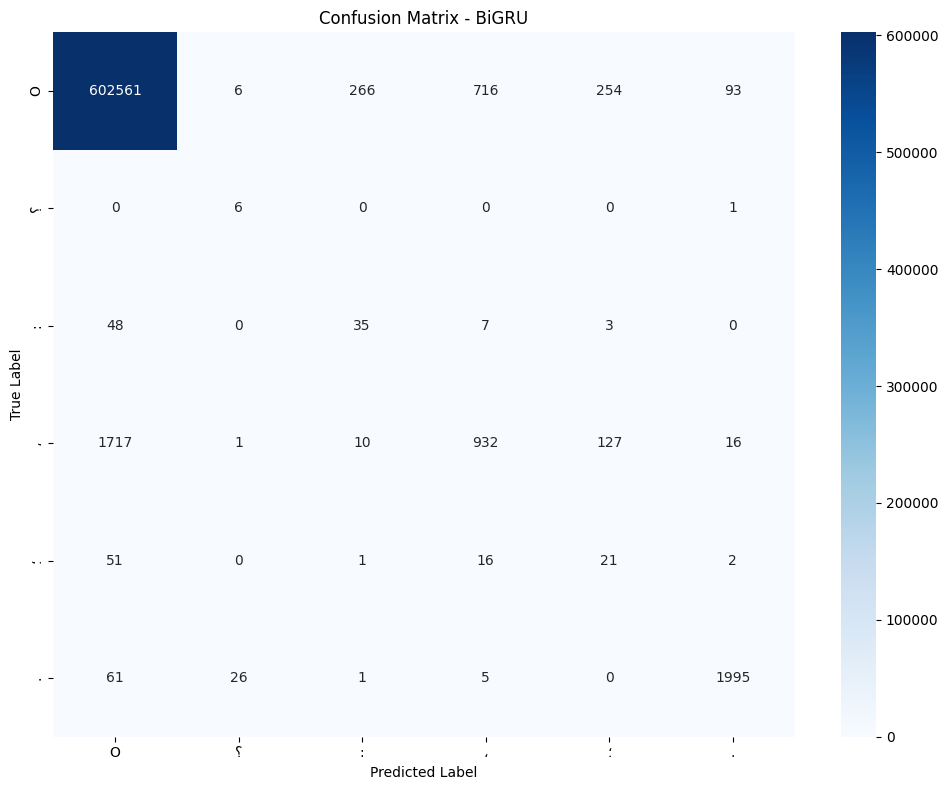

Confusion matrix saved: confusion_matrix_BiGRU.png


In [ ]:
import re
from collections import Counter
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def extract_punctuation_labels(original_text, label_to_punctuation):
    punct_to_label = {v: k for k, v in label_to_punctuation.items() if v != 'O'}
    all_punctuation = set(punct_to_label.keys())
    tokens, labels = [], []
    pattern = r'(\w+|[' + re.escape(''.join(all_punctuation)) + '])'
    parts = re.findall(pattern, original_text)
    o_label = next((k for k, v in label_to_punctuation.items() if v == 'O'), 0)
    i = 0
    while i < len(parts):
        part = parts[i].strip()
        if not part:
            i += 1
            continue
        if part in all_punctuation:
            if tokens:
                labels[-1] = punct_to_label.get(part, o_label)
            i += 1
            continue
        tokens.append(part)
        if i + 1 < len(parts) and parts[i + 1].strip() in all_punctuation:
            labels.append(punct_to_label.get(parts[i + 1].strip(), o_label))
        else:
            labels.append(o_label)
        i += 1
    return tokens, labels

def extract_predicted_labels(predicted_text, label_to_punctuation):
    punct_to_label = {v: k for k, v in label_to_punctuation.items() if v != 'O'}
    all_punctuation = set(punct_to_label.keys())
    o_label = next((k for k, v in label_to_punctuation.items() if v == 'O'), 0)
    tokens, labels = [], []
    parts = predicted_text.split()
    for part in parts:
        if part in all_punctuation:
            if tokens:
                labels[-1] = punct_to_label.get(part, o_label)
            continue
        tokens.append(part)
        labels.append(o_label)
    return tokens, labels

def align_sequences(true_tokens, true_labels, pred_tokens, pred_labels, o_label):
    min_len = min(len(true_tokens), len(pred_tokens))
    aligned_true_labels, aligned_pred_labels = [], []
    for i in range(min_len):
        if true_tokens[i].lower() == pred_tokens[i].lower():
            aligned_true_labels.append(true_labels[i])
            aligned_pred_labels.append(pred_labels[i])
        else:
            aligned_true_labels.append(o_label)
            aligned_pred_labels.append(o_label)
    return aligned_true_labels, aligned_pred_labels

def calculate_metrics(y_true, y_pred, label_to_punctuation):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return {
        'accuracy': accuracy,
        'precision_weighted': precision_w, 'recall_weighted': recall_w, 'f1_weighted': f1_w,
        'precision_macro': precision_m, 'recall_macro': recall_m, 'f1_macro': f1_m,
        'per_class_precision': precision, 'per_class_recall': recall, 'per_class_f1': f1, 'per_class_support': support
    }

def evaluate_single_model(original_sentences, predicted_sentences, label_to_punctuation, model_name):
    o_label = next((k for k, v in label_to_punctuation.items() if v == 'O'), 0)
    all_true_labels, all_pred_labels = [], []
    for orig, pred in zip(original_sentences, predicted_sentences):
        true_tokens, true_labels = extract_punctuation_labels(orig, label_to_punctuation)
        pred_tokens, pred_labels = extract_predicted_labels(pred, label_to_punctuation)
        aligned_true, aligned_pred = align_sequences(true_tokens, true_labels, pred_tokens, pred_labels, o_label)
        all_true_labels.extend(aligned_true)
        all_pred_labels.extend(aligned_pred)
    if not all_true_labels or not all_pred_labels:
        return None
    metrics = calculate_metrics(all_true_labels, all_pred_labels, label_to_punctuation)
    print(f"\n{'─'*80}\nEvaluating: {model_name}\n{'─'*80}")
    print(f"Accuracy: {metrics['accuracy']:.4f}, F1-Weighted: {metrics['f1_weighted']:.4f}, F1-Macro: {metrics['f1_macro']:.4f}")
    return metrics

def compare_all_models(original_sentences, model_predictions, label_to_punctuation):
    all_results = {}
    for model_name, preds in model_predictions.items():
        metrics = evaluate_single_model(original_sentences, preds, label_to_punctuation, model_name)
        if metrics:
            all_results[model_name] = metrics
    comparison_data = []
    for model_name, metrics in all_results.items():
        comparison_data.append({
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision (W)': metrics['precision_weighted'],
            'Recall (W)': metrics['recall_weighted'],
            'F1-Score (W)': metrics['f1_weighted'],
            'F1-Score (M)': metrics['f1_macro']
        })
    df = pd.DataFrame(comparison_data).sort_values('F1-Score (W)', ascending=False)
    best_model = df.iloc[0]['Model']
    best_f1 = df.iloc[0]['F1-Score (W)']
    df.to_excel('models_comparison.xlsx', index=False)
    df.to_csv('models_comparison.csv', index=False)
    print(df.to_string(index=False))
    print(f"\n Best Model: {best_model}, F1-Weighted: {best_f1:.4f}")
    return df, best_model, all_results

#  Confusion Matrix
def plot_confusion_matrix_for_best_model(original_sentences, predicted_sentences, label_to_punctuation, model_name):
    o_label = next((k for k, v in label_to_punctuation.items() if v == 'O'), 0)
    all_true_labels, all_pred_labels = [], []
    for orig, pred in zip(original_sentences, predicted_sentences):
        true_tokens, true_labels = extract_punctuation_labels(orig, label_to_punctuation)
        pred_tokens, pred_labels = extract_predicted_labels(pred, label_to_punctuation)
        aligned_true, aligned_pred = align_sequences(true_tokens, true_labels, pred_tokens, pred_labels, o_label)
        all_true_labels.extend(aligned_true)
        all_pred_labels.extend(aligned_pred)
    cm = confusion_matrix(all_true_labels, all_pred_labels)
    unique_labels = sorted(set(all_true_labels))
    label_names = [label_to_punctuation.get(l, f'L{l}') for l in unique_labels]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()
    print(f"Confusion matrix saved: confusion_matrix_{model_name.replace(' ', '_')}.png")

model_predictions = {'BiLSTM': bilstm_punctuated, 'BiGRU': bigru_punctuated, 'Focal Loss': focal_punctuated}
comparison_df, best_model_name, detailed_results = compare_all_models(raw_sentences, model_predictions, label_to_punctuation)
plot_confusion_matrix_for_best_model(raw_sentences, model_predictions[best_model_name], label_to_punctuation, best_model_name)


# transformers

In [ ]:
!pip install -q datasets
!pip install -q transformers datasets accelerate

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
RANDOM_STATE = 42


X = all_sequences
y = all_labels

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Train: 26149 | Val: 3269 | Test: 3269


## 1)- AraBERT

## v1

<div dir="rtl" >
<h4 >

في هذه الخلية قمنا بتحضير البيانات والموديل لتدريب نموذج بيرت عربي على استعادة الترقيم اول شي عرفنا اسم الموديل وحملنا التوكنيزر وقررنا عدد الفئات حسب علامات الترقيم بعدين جهزنا دالة لتحويل كل جملة إلى توكنات مع محاذاة التسميات الاصليه بحيث كل كلمة تاخذ التصنيف المناسب وتجاهلنا التوكنات الفرعية ثم حولنا البيانات لمجموعات تدريب تحقق واختبار جهزنا الموديل نفسه مع عدد الفئات وربطنا التسميات مع المعرفات بعدين ضبطنا اعدادات التدريب مثل عدد الحلقات وحجم الدفعات وسرعة التعلم واخيرا عرفنا دالة لحساب الدقة متجاهلا الرموز المحشوة وربطنا كل شيء مع الـ Trainer ليكون جاهزا للتدريب

</h4>
</div>

In [ ]:
# طباعة جدول المقارنة المحدّث
comparison_all = print_models_comparison_table(results_all_models, sort_by="F-score")

# حفظ الجدول
comparison_all.to_excel('/content/drive/MyDrive/models/comparison_with_bert.xlsx', index=False)
print("\n✓ جدول المقارنة المحدّث محفوظ على Drive")

In [ ]:
MODEL_NAME = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
NUM_LABELS = len(label_to_punctuation)


In [ ]:
def tokenize_and_align_labels(seqs, labs):
    tokenized = tokenizer(
        seqs,
        is_split_into_words=True,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors=None
    )

    aligned_labels = []

    for i, word_ids in enumerate(tokenized.word_ids(batch_index=i) for i in range(len(seqs))):
        label_ids = []
        prev_word = None

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(PAD_LABEL)
            elif word_id != prev_word:
                label_ids.append(labs[i][word_id])
            else:
                label_ids.append(PAD_LABEL)  # ignore subwords

            prev_word = word_id

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels
    return tokenized


In [ ]:
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score

train_enc = tokenize_and_align_labels(X_train, y_train)
val_enc   = tokenize_and_align_labels(X_val, y_val)
test_enc  = tokenize_and_align_labels(X_test, y_test)

train_dataset = Dataset.from_dict(train_enc)
val_dataset = Dataset.from_dict(val_enc)
test_dataset = Dataset.from_dict(test_enc)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=label_to_punctuation,
    label2id=punctuation_to_label
)

args = TrainingArguments(
    output_dir="./ara_punct",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=-1)
    labels = p.label_ids

    # تجاهل PAD
    mask = labels != PAD_LABEL
    preds_flat = preds[mask]
    labels_flat = labels[mask]

    acc = accuracy_score(labels_flat, preds_flat)
    return {"accuracy": acc}

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3097050876.py:49: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.031000,0.027891,0.962796
2,0.024700,0.027009,0.965629
3,0.020800,0.026125,0.965931
4,0.019100,0.026380,0.966294


Epoch,Training Loss,Validation Loss,Accuracy
1,0.031000,0.027891,0.962796
2,0.024700,0.027009,0.965629
3,0.020800,0.026125,0.965931
4,0.019100,0.026380,0.966294
5,0.016300,0.027511,0.966389


TrainOutput(global_step=8175, training_loss=0.026160547157310927, metrics={'train_runtime': 3212.6025, 'train_samples_per_second': 40.698, 'train_steps_per_second': 2.545, 'total_flos': 8541274416568320.0, 'train_loss': 0.026160547157310927, 'epoch': 5.0})

<div dir="rtl" >
<h4 >

في هذه الخلية قمنا بتقييم نموذج بيرت بعد التدريب اول شي استخدمنا دالة predict الخاصة بالـ Trainer للحصول على التوقعات ثم حولنا المخرجات إلى تسميات فعلية وتوقعات لكل كلمة تجاهلنا الرموز المحشوة بعد ذلك فصلنا الكلمات التي ليست بدون ترقيم O_LABEL وحصلنا على مصفوفات حقيقية ومتوقعة بدون الفئة O واخيرا استخدمنا classification_report لحساب المقاييس لكل فئة مثل الدقة والاسترجاع و F1 وطباعتها بطريقة واضحة

</h4>
</div>

In [ ]:
preds = trainer.predict(test_dataset)
logits = preds.predictions
labels = preds.label_ids

y_true, y_pred = [], []

for p, l in zip(logits, labels):
    for pi, li in zip(p.argmax(axis=-1), l):
        if li != PAD_LABEL:
            y_true.append(li)
            y_pred.append(pi)


In [ ]:
mask = np.array(y_true) != O_LABEL

y_true_no_o = np.array(y_true)[mask]
y_pred_no_o = np.array(y_pred)[mask]

labels_no_o = sorted(set(y_true_no_o))
label_names_no_o = [label_to_punctuation[i] for i in labels_no_o]

print(classification_report(
    y_true_no_o,
    y_pred_no_o,
    labels=labels_no_o,
    target_names=label_names_no_o,
    digits=4,
    zero_division=0
))


              precision    recall  f1-score   support

           ؟     0.9711    0.9626    0.9668       908
           :     0.9394    0.8494    0.8921      1076
           ،     0.9277    0.7297    0.8169      6189
           ؛     0.8491    0.7883    0.8175      1856
           !     0.6885    0.4330    0.5316        97
           .     0.9952    0.9912    0.9932      2728

   micro avg     0.9352    0.8179    0.8726     12854
   macro avg     0.8952    0.7924    0.8364     12854
weighted avg     0.9329    0.8179    0.8691     12854



### Real Test Set Validation




<div dir="rtl" >
<h4 >

في هذه الخلية أنشأنا دالة لإضافة الترقيم لجملة واحدة الدالة تأخذ الجملة والنموذج والـ tokenizer وخريطة التسمية أول شي قسمنا الجملة لكلمات ثم حولناها إلى مدخلات مناسبة للنموذج مع تقطيع وملء حتى طول ثابت بعد ذلك استخدمنا النموذج لتوقع فئة كل كلمة ثم أعدنا بناء الجملة مع إضافة العلامات المتوقعة بعد كل كلمة متى ما كانت موجودة وتجاهلنا الرموز المحشوة والفئة O


</h4>
</div>

In [ ]:
def punctuate_sentence(sentence, model, tokenizer, label_to_punctuation, max_len=128):
    # قسم الجملة لكلمات
    words = sentence.split()

    tokenized = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len
    )

    word_ids = tokenized.word_ids(batch_index=0)

    tokenized = {k: v.to(model.device) for k, v in tokenized.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**tokenized)
    logits = outputs.logits
    pred_ids = logits.argmax(-1).squeeze().tolist()

    punctuated = ""
    last_word_id = None

    for token_idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue

        if word_id != last_word_id:
            if punctuated:
                punctuated += " "
            punctuated += words[word_id]

            label_id = pred_ids[token_idx]
            label = label_to_punctuation.get(label_id, "")
            if label not in ("<PAD>", "O"):
                punctuated += label

        last_word_id = word_id

    return punctuated


In [ ]:
long_text = (
    "في صباح يوم مشمس خرجت فاطمة من بيتها متجهة نحو السوق. "
    "كانت تحمل حقيبة صغيرة بداخلها بعض النقود والخضار التي تحتاجها للعائلة. "
    "بينما تمشي في الطريق شاهدت أطفالًا يلعبون بالكرة، وضحكت لرؤيتهم. "
    "اقتربت من البائع الذي يعرفه منذ سنوات واشترت الفواكه والخضار الطازجة. "
    "بعد التسوق عادت إلى بيتها لتجهز وجبة الغداء، لكنها تذكرت أن عليها الاتصال بصديقتها لتطمئن عليها."
)

punctuated_text = punctuate_sentence(long_text, model, tokenizer, label_to_punctuation)
print(punctuated_text)


في صباح يوم مشمس، خرجت فاطمة من بيتها متجهة نحو السوق. كانت تحمل حقيبة صغيرة بداخلها بعض النقود والخضار التي تحتاجها للعائلة.؛ بينما تمشي في الطريق، شاهدت أطفالًا يلعبون بالكرة، وضحكت لرؤيتهم. اقتربت من البائع الذي يعرفه منذ سنوات واشترت الفواكه والخضار الطازجة. بعد التسوق، عادت إلى بيتها لتجهز وجبة الغداء، لكنها تذكرت أن عليها الاتصال بصديقتها لتطمئن عليها.


## جرب vlaidation data



In [ ]:
# --------------------------
# 1) قراءة ملف من ملفات التدريب
# --------------------------

REAL_TEST_PATH = "./data_SSAC_UNPC/SSAC-UNPC/UNPC_Sentences_79.txt"

sample_file = os.path.join(data_folder, "UNPC_Sentences_79.txt")  # غير الاسم لملف موجود
with open(sample_file, 'r', encoding='utf-8') as f:
    raw_lines = [line.strip() for line in f if line.strip()]

# تنظيف الجمل بنفس الطريقة
cleaned_lines = [normalize_sentence(line) for line in raw_lines]

# --------------------------
# 2) تحويل الجمل لتوكن + استدعاء الموديل
# --------------------------
def punctuate_lines(lines, model, tokenizer, label_to_punctuation, max_len=128):
    results = []
    for sent in lines:
        punctuated = punctuate_sentence(sent, model, tokenizer, label_to_punctuation, max_len=max_len)
        results.append(punctuated)
    return results

punctuated_lines = punctuate_lines(cleaned_lines, model, tokenizer, label_to_punctuation)

# --------------------------
# 3) عرض النتائج
# --------------------------
for orig, punct in zip(cleaned_lines[:10], punctuated_lines[:10]):
    print(f"Original : {orig}")
    print(f"Punctuated: {punct}\n")


Original : 34- تلقت امانة الاونكتاد طلبين للادراج في القائمة المنصوص عليها في المادة 77 من النظام الداخلي للمجلس.
Punctuated: 34- تلقت امانة الاونكتاد طلبين للادراج في القائمة المنصوص عليها في المادة 77 من النظام الداخلي للمجلس.

Original : 35- وترد قائمة بالمنظمات غير الحكومية المعتمدة في الوثيقة TD/B/NGO/LIST/16.
Punctuated: 35- وترد قائمة بالمنظمات غير الحكومية المعتمدة في الوثيقة TD/B/NGO/LIST/16.

Original : 36- سيُعرض على المجلس الجدول الزمني لاجتماعات الفترة المتبقية من عام 2014 وعام 2015.
Punctuated: 36- سيُعرض على المجلس الجدول الزمني لاجتماعات الفترة المتبقية من عام 2014 وعام 2015.؛

Original : 37- سيُطلب الى المجلس الموافقة على عضوية الفرقة العاملة لعام 2015 على اساس الترشيحات المقدمة من المجموعات الاقليمية.
Punctuated: 37- سيُطلب الى المجلس الموافقة على عضوية الفرقة العاملة لعام 2015 على اساس الترشيحات المقدمة من المجموعات الاقليمية.

Original : 38- ستُعرض على المجلس، بحسب الاقتضاء، القائمة المحدثة التي تضم اعضاء الاونكتاد والمجلس.
Punctuated: 38- ستُعرض على المجلس، بحسب ال

<div dir="rtl" >
<h4 >


</h4>
</div>

In [ ]:
def punctuate_sentence(sentence, model, tokenizer, label_to_punctuation, max_len=128):
    words = sentence.split()
    tokenized = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len
    )
    word_ids = tokenized.word_ids(batch_index=0)
    tokenized = {k: v.to(model.device) for k, v in tokenized.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**tokenized)
    logits = outputs.logits
    pred_ids = logits.argmax(-1).squeeze().tolist()

    punctuated = ""
    last_word_id = None
    for token_idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        if word_id != last_word_id:
            if punctuated:
                punctuated += " "
            punctuated += words[word_id]

            label_id = pred_ids[token_idx]
            label = label_to_punctuation.get(label_id, "")
            if label not in ("<PAD>", "O"):
                punctuated += label
        last_word_id = word_id

    return punctuated


## v2

In [ ]:

# Custom Class Weights (V3 Improved)
print("\n Computing V3 Class Weights...")

train_labels_flat = [l for seq in y_train for l in seq if l != PAD_LABEL]
computed_weights = compute_class_weight('balanced', classes=np.unique(train_labels_flat), y=train_labels_flat)

custom_weights = torch.ones(NUM_LABELS).to(device)
weight_dict = {cls: w for cls, w in zip(np.unique(train_labels_flat), computed_weights)}

for label_id in range(NUM_LABELS):
    if label_id == PAD_LABEL:
        custom_weights[label_id] = 0.0 #نخبر الموديل ألا يهتم أبداً بحشو الكلام (Padding)
    elif label_id == O_LABEL:
        custom_weights[label_id] = max(0.4, weight_dict.get(label_id, 1.0))
    elif label_id == punctuation_to_label.get('؛', 5):
        w = weight_dict.get(label_id, 1.0)
        custom_weights[label_id] = min(w * 0.7, 3.5)
    elif label_id == punctuation_to_label.get('،', 4):
        w = weight_dict.get(label_id, 1.0)
        custom_weights[label_id] = min(w * 1.3, 6.0)
    elif label_id == punctuation_to_label.get('!', 6):
        w = weight_dict.get(label_id, 1.0)
        custom_weights[label_id] = min(w * 1.2, 7.0)
    else:
        w = weight_dict.get(label_id, 1.0)
        custom_weights[label_id] = min(w, 5.0)

print("V3 Custom Weights:", custom_weights.tolist())

#  Weighted Trainer :inhereted from hugging face to use our own custom weight
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=custom_weights)
        loss = loss_fct(logits.view(-1, NUM_LABELS), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=-1)
    labels = p.label_ids
    mask = labels != PAD_LABEL
    preds_flat = preds[mask]
    labels_flat = labels[mask]
    acc = accuracy_score(labels_flat, preds_flat)
    return {"accuracy": acc}

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=label_to_punctuation,
    label2id=punctuation_to_label
).to(device)

args = TrainingArguments(
    output_dir="./ara_bert_v3_ultra",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=5e-6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,              # أكثر من V2 (كان 6)
    weight_decay=0.015,             # لمنع الـ Overfitting
    warmup_ratio=0.15,               #  في أول 15% من التدريب، يبدأ معدل التعلم من 0 ويزيد تدريجياً. لتجنب صدمة الموديل في بداية التدريب بأوزان عشوائية،    .
    label_smoothing_factor=0.15,     # (يقلل Overconfidence)
    max_grad_norm=0.8,               # Gradient Clipping أقوى
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none",
    fp16=True  # تسريع
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, padding='max_length', max_length=256)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


print("\n Starting BERT V3 Training...")
trainer.train()

print("\n EVALUATING ON TEST SET...")
test_preds = trainer.predict(test_dataset)
test_logits = test_preds.predictions
test_labels = test_preds.label_ids

y_true_final, y_pred_final = [], []
for p, l in zip(test_logits, test_labels):
    for pi, li in zip(p.argmax(axis=-1), l):
        if li != PAD_LABEL:
            y_true_final.append(li)
            y_pred_final.append(pi)

y_true_final = np.array(y_true_final)
y_pred_final = np.array(y_pred_final)

mask = y_true_final != O_LABEL
print("\n Test Results (Punctuation Only):")
print(classification_report(
    y_true_final[mask], y_pred_final[mask],
    labels=sorted(set(y_true_final[mask])),
    target_names=[label_to_punctuation[i] for i in sorted(set(y_true_final[mask]))],
    digits=4, zero_division=0
))

SAVE_PATH = "/content/drive/MyDrive/models/BERT_V3_Ultra"
os.makedirs(SAVE_PATH, exist_ok=True)
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"\n BERT V3 saved to: {SAVE_PATH}")

✓ Sampled: 32,690 sentences
✓ Split: Train=26149, Val=3269, Test=3269


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...


 Starting BERT V3 Training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.340400,0.303250,0.924962
2,0.259900,0.230320,0.941963
3,0.208700,0.215204,0.938715
4,0.193100,0.210715,0.945456


Epoch,Training Loss,Validation Loss,Accuracy
1,0.340400,0.303250,0.924962
2,0.259900,0.230320,0.941963
3,0.208700,0.215204,0.938715
4,0.193100,0.210715,0.945456
5,0.173700,0.213831,0.943341
6,0.159800,0.214154,0.945258
7,0.168600,0.215043,0.947476
8,0.146100,0.214483,0.946470



 EVALUATING ON TEST SET...



 Test Results (Punctuation Only):
              precision    recall  f1-score   support

           ؟     0.9603    0.9613    0.9608       930
           :     0.9134    0.8867    0.8998      1094
           ،     0.9495    0.8835    0.9153      7132
           ؛     0.8513    0.8468    0.8491      2089
           !     0.5862    0.5258    0.5543        97
           .     0.9898    0.9950    0.9924      2827

   micro avg     0.9385    0.9032    0.9206     14169
   macro avg     0.8751    0.8498    0.8620     14169
weighted avg     0.9385    0.9032    0.9202     14169


 BERT V3 saved to: /content/drive/MyDrive/models/BERT_V3_Ultra


## v3

In [ ]:

# ==========================================
# 5. التدريب المخصص (Custom Trainer)
# ==========================================
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    predictions, labels = p
    preds = np.argmax(predictions, axis=2)

    true_predictions = [
        [label_to_punctuation[p] for (p, l) in zip(pred, label) if l != PAD_LABEL]
        for pred, label in zip(preds, labels)
    ]
    true_labels = [
        [label_to_punctuation[l] for (p, l) in zip(pred, label) if l != PAD_LABEL]
        for pred, label in zip(preds, labels)
    ]

    # تحويل القوائم إلى مصفوفة مسطحة لحساب الدقة
    flat_preds = [item for sublist in true_predictions for item in sublist]
    flat_labels = [item for sublist in true_labels for item in sublist]

    return {
        "accuracy": accuracy_score(flat_labels, flat_preds),
    }


# هـ) حساب الأوزان للفئات (Class Weights)
print("[INFO] Calculating class weights...")
flat_train_labels = [l for sublist in train_labels_raw for l in sublist]
class_weights = compute_class_weight('balanced', classes=np.unique(flat_train_labels), y=flat_train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

final_weights = torch.ones(NUM_LABELS).to(device)
for idx, weight in enumerate(class_weights):
    if idx < NUM_LABELS:
        final_weights[idx] = weight
final_weights[PAD_LABEL] = 0 # تجاهل الـ Padding في الحساب

print("[INFO] Loading Model...")
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=label_to_punctuation,
    label2id=punctuation_to_label
).to(device)

args = TrainingArguments(
    output_dir="./bert_punct_output",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    save_total_limit=1,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

print("[INFO] Starting training...")
trainer = WeightedTrainer(
    class_weights=final_weights,
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorForTokenClassification(tokenizer),
    compute_metrics=compute_metrics
)

trainer.train()

print("\n[INFO] Evaluating on Test Set...")
results = trainer.evaluate(test_dataset)
print(f"\n****** Final Accuracy: {results['eval_accuracy']:.4f} ******\n")

predictions, labels, _ = trainer.predict(test_dataset)
preds = np.argmax(predictions, axis=2)

true_preds = []
true_labs = []

for i in range(len(labels)):
    for j in range(len(labels[i])):
        if labels[i][j] != PAD_LABEL:
            true_preds.append(label_to_punctuation[preds[i][j]])
            true_labs.append(label_to_punctuation[labels[i][j]])

print(classification_report(true_labs, true_preds, zero_division=0))

# ==========================================
# 8. الحفظ والتجربة
# ==========================================
save_path = "/content/drive/MyDrive/BERT_Final_Model"
print(f"[INFO] Saving model to {save_path}...")
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

def punctuate_text(text):
    words = text.split()
    tokens = tokenizer(words, is_split_into_words=True, return_tensors="pt",  padding=True, truncation=True, max_length=MAX_LEN).to(device)

    with torch.no_grad():
        logits = model(**tokens).logits

    predictions = torch.argmax(logits, dim=2).squeeze().tolist()
    word_ids = tokens.word_ids()

    result = ""
    last_wid = None

    for i, wid in enumerate(word_ids):
        if wid is None: continue
        if wid != last_wid:
            if result: result += " "
            result += words[wid]

            lbl = label_to_punctuation[predictions[i]]
            if lbl not in ['<PAD>', 'O']:
                result += lbl
        last_wid = wid
    return result

print("\n--- Test Example ---")
sample_text = "السلام عليكم كيف حالك اليوم هل ستذهب إلى العمل أم ستبقى في المنزل"
print(f"Original: {sample_text}")
print(f"Result:   {punctuate_text(sample_text)}")

Mounted at /content/drive
[INFO] Downloading dataset...
[INFO] Reading text files from /content/local_data/SSAC-UNPC...
[INFO] Total raw sentences: 11731359
[INFO] Cleaning and balancing dataset (this may take a moment)...
[INFO] balanced dataset size: 40676
[INFO] Loading Tokenizer...


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

[INFO] Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.080900,0.079206,0.961120


Epoch,Training Loss,Validation Loss,Accuracy
1,0.080900,0.079206,0.961120
2,0.056700,0.079850,0.964477
3,0.043600,0.084470,0.965460



[INFO] Evaluating on Test Set...



****** Final Accuracy: 0.9659 ******

              precision    recall  f1-score   support

           !       0.75      0.03      0.06        95
           .       0.99      0.94      0.97      5424
           :       0.96      0.59      0.73      1742
           O       0.98      0.99      0.99    240090
           ،       0.81      0.38      0.52      9672
           ؛       0.58      0.94      0.72      3405
           ؟       0.87      0.94      0.90      1565

    accuracy                           0.97    261993
   macro avg       0.85      0.69      0.70    261993
weighted avg       0.97      0.97      0.96    261993

[INFO] Saving model to /content/drive/MyDrive/BERT_Final_Model...

--- Test Example ---
Original: السلام عليكم كيف حالك اليوم هل ستذهب إلى العمل أم ستبقى في المنزل
Result:   السلام عليكم، كيف حالك اليوم، هل ستذهب إلى العمل أم ستبقى في المنزل؟


## 2)- AraELECTRA

<div dir="rtl" >
<h4 >

في هذه الخلية قمنا بتحضير البيانات للجمل العربية مع ترقيمها وحساب التسميات لكل كلمة بعد إزالة الرموز الغير ضرورية ثم قسمنا البيانات لمجموعات تدريب وتحقق واختبار بعد ذلك استخدمنا موديل AraELECTRA مع التوكنيزر الخاص به وعيّنا عدد التسميات ثم عرفنا دالة لمزامنة التسميات مع التوكنز الناتجة من التوكنيزر بعدها أنشأنا الـ Dataset الخاص بـ HuggingFace وأعددنا موديل TokenClassification مع Trainer لتدريب الموديل وحساب الدقة بعد التدريب اختبرنا الموديل على جمل قصيرة وطويلة كما طبّقنا نفس العملية على بعض الجمل من ملف نصي حقيقي لعرض النتيجة قبل وبعد الترقيم


</h4>
</div>

In [ ]:
label_to_punctuation = {0: '<PAD>', 1: 'O', 2: '؟', 3: ':', 4: '،', 5: '؛', 6: '!', 7: '.'}
punctuation_to_label = {v: k for k, v in label_to_punctuation.items()}
PAD_LABEL = 0
O_LABEL = 1
PUNCT_SET = set(['؟', '!', '؛', ':', '،', '.'])
PUNCT_PRIORITY = {'؟': 6, '!': 5, '.': 4, '؛': 3, ':': 2, '،': 1}
WRAPPERS_RE = re.compile(r'[«»"”“\(\)\[\]\{\}]')

def extract_words_and_labels(sentence: str, O_LABEL=1):
    s = str(sentence)
    s = WRAPPERS_RE.sub(' ', s)
    s = re.sub(r'([؟!؛:،.])', r' \1 ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    tokens = s.split()
    words, labels = [], []
    for tok in tokens:
        if tok in PUNCT_SET:
            if labels:
                new_lab = punctuation_to_label[tok]
                cur_lab = labels[-1]
                if cur_lab == O_LABEL:
                    labels[-1] = new_lab
                else:
                    cur_sym = label_to_punctuation[cur_lab]
                    if PUNCT_PRIORITY.get(tok, 0) > PUNCT_PRIORITY.get(cur_sym, 0):
                        labels[-1] = new_lab
            continue
        words.append(tok)
        labels.append(O_LABEL)
    return words, labels

print("Extracting token sequences and labels...")
all_sequences, all_labels = [], []
for i, sentence in enumerate(df_sampled['Sentence'], 1):
    w, l = extract_words_and_labels(sentence, O_LABEL=O_LABEL)
    if w:
        all_sequences.append(w)
        all_labels.append(l)
    if i % 1000 == 0:
        print(f"Processed {i}/{len(df_sampled)} sentences")

sequence_lengths = [len(seq) for seq in all_sequences]

training_data = {
    "sequences": all_sequences,
    "labels": all_labels,
    "sequence_lengths": sequence_lengths,
    "label_to_punctuation": label_to_punctuation,
    "punctuation_to_label": punctuation_to_label,
    "PAD_LABEL": PAD_LABEL,
    "O_LABEL": O_LABEL,
    "df_sampled": df_sampled,
}

EXCL_LABEL = punctuation_to_label['!']
n_excl = sum(x == EXCL_LABEL for seq in all_labels for x in seq)

print("df_sampled counts:\n", df_sampled["punct"].value_counts())
print("Token labels '!':", n_excl)
print("Sentences labeled '!':", int((df_sampled["punct"] == "!").sum()))
print("Total sequences:", len(all_sequences))


In [ ]:

!pip install -q transformers datasets accelerate

import numpy as np
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from datasets import Dataset


RANDOM_STATE = 42

X = all_sequences
y = all_labels

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

MODEL_NAME = "aubmindlab/araelectra-base-discriminator"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
NUM_LABELS = len(label_to_punctuation)

print(f" Loaded: {MODEL_NAME}")
print(f" Labels: {label_to_punctuation}")

def tokenize_and_align_labels(seqs, labs):
    tokenized = tokenizer(
        seqs,
        is_split_into_words=True,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors=None
    )

    aligned_labels = []

    for i in range(len(seqs)):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word = None

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(PAD_LABEL)
            elif word_id != prev_word:
                label_ids.append(labs[i][word_id])
            else:
                label_ids.append(PAD_LABEL)
            prev_word = word_id

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels
    return tokenized


train_enc = tokenize_and_align_labels(X_train, y_train)
val_enc = tokenize_and_align_labels(X_val, y_val)
test_enc = tokenize_and_align_labels(X_test, y_test)

train_dataset = Dataset.from_dict(train_enc)
val_dataset = Dataset.from_dict(val_enc)
test_dataset = Dataset.from_dict(test_enc)

print(" Datasets created")


model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=label_to_punctuation,
    label2id=punctuation_to_label
)

print(" Model loaded")


args = TrainingArguments(
    output_dir="./araelectra_punct",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,  # أعلى شوي من BERT
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    fp16=True,  # تسريع
    report_to="none"
)


Train: 26149 | Val: 3269 | Test: 3269


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

 Loaded: aubmindlab/araelectra-base-discriminator
 Labels: {0: '<PAD>', 1: 'O', 2: '؟', 3: ':', 4: '،', 5: '؛', 6: '!', 7: '.'}
 Datasets created


model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Some weights of ElectraForTokenClassification were not initialized from the model checkpoint at aubmindlab/araelectra-base-discriminator and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Model loaded


In [ ]:


def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=-1)
    labels = p.label_ids

    mask = labels != PAD_LABEL
    preds_flat = preds[mask]
    labels_flat = labels[mask]

    acc = accuracy_score(labels_flat, preds_flat)
    return {"accuracy": acc}


In [ ]:


trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("\n Starting AraELECTRA training...\n")
trainer.train()


/tmp/ipython-input-3487671636.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



 Starting AraELECTRA training...



Epoch,Training Loss,Validation Loss,Accuracy
1,0.035100,0.031389,0.959860
2,0.025800,0.028210,0.963720
3,0.021100,0.026976,0.964808


Epoch,Training Loss,Validation Loss,Accuracy
1,0.035100,0.031389,0.959860
2,0.025800,0.028210,0.963720
3,0.021100,0.026976,0.964808
4,0.017500,0.028659,0.964385
5,0.014000,0.030631,0.964549


TrainOutput(global_step=8175, training_loss=0.051839748755872064, metrics={'train_runtime': 1322.7343, 'train_samples_per_second': 98.844, 'train_steps_per_second': 6.18, 'total_flos': 8541274416568320.0, 'train_loss': 0.051839748755872064, 'epoch': 5.0})

In [ ]:


preds = trainer.predict(test_dataset)
logits = preds.predictions
labels = preds.label_ids

y_true, y_pred = [], []

for p, l in zip(logits, labels):
    for pi, li in zip(p.argmax(axis=-1), l):
        if li != PAD_LABEL:
            y_true.append(li)
            y_pred.append(pi)



mask = np.array(y_true) != O_LABEL
y_true_no_o = np.array(y_true)[mask]
y_pred_no_o = np.array(y_pred)[mask]

labels_no_o = sorted(set(y_true_no_o))
label_names_no_o = [label_to_punctuation[i] for i in labels_no_o]

print("\n" + "="*80)
print(" AraELECTRA RESULTS (punctuation only)".center(80))
print("="*80)
print(classification_report(
    y_true_no_o,
    y_pred_no_o,
    labels=labels_no_o,
    target_names=label_names_no_o,
    digits=4,
    zero_division=0
))



                      AraELECTRA RESULTS (punctuation only)                     
              precision    recall  f1-score   support

           ؟     0.9523    0.9460    0.9492       908
           :     0.9466    0.8401    0.8902      1076
           ،     0.9257    0.7192    0.8095      6189
           ؛     0.8502    0.7796    0.8134      1856
           !     0.8000    0.2474    0.3780        97
           .     0.9915    0.9890    0.9903      2728

   micro avg     0.9339    0.8078    0.8663     12854
   macro avg     0.9111    0.7536    0.8051     12854
weighted avg     0.9315    0.8078    0.8618     12854



In [ ]:


def punctuate_sentence(sentence, model, tokenizer, label_to_punctuation, max_len=128):
    words = sentence.split()
    tokenized = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len
    )
    word_ids = tokenized.word_ids(batch_index=0)
    tokenized = {k: v.to(model.device) for k, v in tokenized.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**tokenized)
    logits = outputs.logits
    pred_ids = logits.argmax(-1).squeeze().tolist()

    punctuated = ""
    last_word_id = None
    for token_idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        if word_id != last_word_id:
            if punctuated:
                punctuated += " "
            punctuated += words[word_id]

            label_id = pred_ids[token_idx]
            label = label_to_punctuation.get(label_id, "")
            if label not in ("<PAD>", "O"):
                punctuated += label
        last_word_id = word_id

    return punctuated


test_sentences = [
    "ذهبت اليوم إلى السوق وجدت بعض الفواكه والخضار",
    "هل تستطيع مساعدتي في حل هذا اللغز الصعب",
    "يا الهي",
    "واو",
    "قال احمد انا احب الحياة"
]

print("\n" + "="*80)
print(" Testing AraELECTRA on sample sentences".center(80))
print("="*80 + "\n")

for sent in test_sentences:
    punctuated = punctuate_sentence(sent, model, tokenizer, label_to_punctuation)
    print(f"Original  : {sent}")
    print(f"Punctuated: {punctuated}\n")

long_text = (
    "في صباح يوم مشمس خرجت فاطمة من بيتها متجهة نحو السوق "
    "كانت تحمل حقيبة صغيرة بداخلها بعض النقود والخضار التي تحتاجها للعائلة "
    "بينما تمشي في الطريق شاهدت أطفالًا يلعبون بالكرة وضحكت لرؤيتهم "
    "اقتربت من البائع الذي يعرفه منذ سنوات واشترت الفواكه والخضار الطازجة"
)

print("Long text test:")
print(punctuate_sentence(long_text, model, tokenizer, label_to_punctuation))


sample_file = os.path.join(data_folder, "UNPC_Sentences_79.txt")
with open(sample_file, 'r', encoding='utf-8') as f:
    raw_lines = [line.strip() for line in f if line.strip()]

cleaned_lines = [normalize_sentence(line) for line in raw_lines]

def punctuate_lines(lines, model, tokenizer, label_to_punctuation, max_len=128):
    results = []
    for sent in lines:
        punctuated = punctuate_sentence(sent, model, tokenizer, label_to_punctuation, max_len=max_len)
        results.append(punctuated)
    return results

punctuated_lines = punctuate_lines(cleaned_lines[:10], model, tokenizer, label_to_punctuation)

print("\n" + "="*80)
print(" Testing on real file".center(80))
print("="*80 + "\n")

for orig, punct in zip(cleaned_lines[:10], punctuated_lines[:10]):
    print(f"Original  : {orig}")
    print(f"Punctuated: {punct}\n")

print(" AraELECTRA pipeline complete!")


                     Testing AraELECTRA on sample sentences                     

Original  : ذهبت اليوم إلى السوق وجدت بعض الفواكه والخضار
Punctuated: ذهبت اليوم إلى السوق وجدت بعض الفواكه والخضار.

Original  : هل تستطيع مساعدتي في حل هذا اللغز الصعب
Punctuated: هل تستطيع مساعدتي في حل هذا اللغز الصعب؟

Original  : يا الهي
Punctuated: يا الهي؟

Original  : واو
Punctuated: واو.

Original  : قال احمد انا احب الحياة
Punctuated: قال احمد: انا احب الحياة.

Long text test:
في صباح يوم مشمس، خرجت فاطمة من بيتها متجهة نحو السوق، كانت تحمل حقيبة صغيرة بداخلها بعض النقود والخضار التي تحتاجها للعائلة، بينما تمشي في الطريق، شاهدت أطفالًا يلعبون بالكرة وضحكت لرؤيتهم، اقتربت من البائع الذي يعرفه منذ سنوات واشترت الفواكه والخضار الطازجة.

                              Testing on real file                              

Original  : 34- تلقت امانة الاونكتاد طلبين للادراج في القائمة المنصوص عليها في المادة 77 من النظام الداخلي للمجلس.
Punctuated: 34- تلقت امانة الاونكتاد طلبين للادراج في القائمة المنص

# saving the index

In [ ]:
import pickle

# مسار الحفظ على Drive
RESULTS_PATH = '/content/drive/MyDrive/models/results_all_models.pkl'

# حفظ الفهرس
with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(results_all_models, f)

print(f"✓ الفهرس محفوظ في: {RESULTS_PATH}")

  
# **a new session**

<div dir="rtl" >
<h4 >

هنا يبدأ التجريب الفعلي على النماذج المدربة
يبدأ تشغيل الكود من هنا

</h4>
</div>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## loading the models

<div dir="rtl" >
<h4 >
 هنا قمنا بجلب النماذج المحفوظة من الدرايف لتجريبها

</h4>
</div>

In [ ]:


LOAD_DIR = '/content/drive/MyDrive/models/'

# نسخ للسيشن الحالي
!cp {LOAD_DIR}/*.pt .
!cp {LOAD_DIR}/*.pkl .
!cp {LOAD_DIR}/*.keras .

print(" Models loaded from Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Models loaded from Drive!


In [ ]:
!ls -lh /content/drive/MyDrive/models | egrep "focal|bilstm|bigru" || true

-rw------- 1 root root  49M Dec 26 16:01 best_bilstm_punct.pt
-rw------- 1 root root 885K Dec 26 16:07 bigru_config.pkl
-rw------- 1 root root  76M Dec 26 16:07 bigru_punctuation.keras
-rw------- 1 root root 683K Dec 26 16:01 bilstm_config.pkl
-rw------- 1 root root 885K Dec 26 16:07 focal_config.pkl
-rw------- 1 root root 162M Dec 26 16:07 focal_loss_moderate_weights.keras


## testing the models

<div dir="rtl" >
<h4 >

 في هذه الخلية حملنا ثلاثة نماذج مختلفة BiLSTM و BiGRU و Focal Loss لكل نموذج جهزنا القاموس الخاص بالكلمات وخريطة التسمية ثم عرفنا دالة لاختبار أي جملة واحدة الدالة تأخذ النص واسم النموذج وتقوم بتحويل الكلمات إلى أرقام مناسبة للنموذج ثم تستخدم النموذج لتوقع فئة كل كلمة وأعدنا بناء الجملة مع إضافة الترقيم المتوقع بعد كل كلمة وأخيرا اختبرنا مجموعة من الجمل على جميع النماذج وعرضنا النتائج بشكل مرتب


</h4>
</div>

In [ ]:
import torch
import torch.nn as nn
import tensorflow as tf
import pickle
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

print(" Loading models...")

with open('bilstm_config.pkl', 'rb') as f:
    bilstm_config = pickle.load(f)

vocab = bilstm_config['vocab']
label_to_punctuation = bilstm_config['label_to_punctuation']
VOCAB_SIZE = bilstm_config['vocab_size']
NUM_CLASSES = bilstm_config['num_classes']

class BiLSTM_Punctuation(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=256, num_classes=8,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths=None):
        embedded = self.dropout(self.embedding(x))
        if lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(
                embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            rnn_out, _ = self.rnn(packed)
            rnn_out, _ = nn.utils.rnn.pad_packed_sequence(rnn_out, batch_first=True)
        else:
            rnn_out, _ = self.rnn(embedded)
        return self.fc(self.dropout(rnn_out))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bilstm_model = BiLSTM_Punctuation(VOCAB_SIZE, 256, 256, NUM_CLASSES, 2, 0.3).to(device)
bilstm_model.load_state_dict(torch.load('best_bilstm_punct.pt', map_location=device))
bilstm_model.eval()
print(" BiLSTM loaded")

with open('bigru_config.pkl', 'rb') as f:
    bigru_config = pickle.load(f)

word_to_id_bigru = bigru_config['word_to_id']
bigru_model = tf.keras.models.load_model('bigru_punctuation.keras')
print(" BiGRU loaded")

with open('focal_config.pkl', 'rb') as f:
    focal_config = pickle.load(f)

word_to_id_focal = focal_config.get('word_to_id', word_to_id_bigru)  # استخدام bigru vocab كـ fallback
MAX_LEN_FOCAL = focal_config.get('max_len', 128)

class FocalLossWeighted(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        p_t = tf.reduce_sum(y_pred * y_true_one_hot, axis=-1)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        ce = -tf.math.log(p_t)
        if self.class_weights is not None:
            alpha_t = tf.gather(self.class_weights, y_true)
            focal_weight = focal_weight * alpha_t
        return focal_weight * ce

focal_model = tf.keras.models.load_model(
    'focal_loss_moderate_weights.keras',
    custom_objects={'FocalLossWeighted': FocalLossWeighted}
)
print(" Focal Loss loaded")

def test_punctuation(text, model_name='bilstm'):
    """اختبار جملة واحدة على أحد الموديلات الثلاثة"""
    words = text.split()

    if model_name == 'bilstm':
        # BiLSTM (PyTorch)
        word_ids = [vocab.get(w, vocab.get('<UNK>', 1)) for w in words]
        x = torch.tensor([word_ids], dtype=torch.long).to(device)
        with torch.no_grad():
            logits = bilstm_model(x)
            preds = logits.argmax(dim=-1)[0].cpu().tolist()

    elif model_name == 'bigru':
        # BiGRU (TensorFlow)
        MAX_LEN = 128
        X = np.zeros((1, MAX_LEN), dtype=np.int32)
        for i, w in enumerate(words[:MAX_LEN]):
            X[0, i] = word_to_id_bigru.get(w, 1)
        probs = bigru_model.predict(X, verbose=0)
        preds = probs[0, :len(words)].argmax(axis=-1).tolist()

    elif model_name == 'focal':
        # Focal Loss Model (TensorFlow)
        X = np.zeros((1, MAX_LEN_FOCAL), dtype=np.int32)
        for i, w in enumerate(words[:MAX_LEN_FOCAL]):
            X[0, i] = word_to_id_focal.get(w, 1)
        probs = focal_model.predict(X, verbose=0)
        preds = probs[0, :len(words)].argmax(axis=-1).tolist()

    else:
        raise ValueError(f"Unknown model: {model_name}. Choose 'bilstm', 'bigru', or 'focal'")

    result = []
    for word, label in zip(words, preds):
        punct = label_to_punctuation.get(label, 'O')
        if punct != 'O' and punct != '<PAD>':
            result.append(word + punct)
        else:
            result.append(word)

    return ' '.join(result)

print("\n" + "="*80)
print("TESTING ALL THREE MODELS".center(80))
print("="*80)

test_cases = [
    "مرحبا كيف حالك اليوم",
    "ما هو اسمك من أين أنت",
    "الطقس جميل اليوم أليس كذلك",
    "هل تحب القراءة أنا أحب الكتب كثيرا",
    "السماء صافية والشمس مشرقة"
]

for i, sent in enumerate(test_cases, 1):
    print(f"\n{'─'*80}")
    print(f" Test Case {i}:")
    print(f" Input:  {sent}")
    print(f"{'─'*80}")

    try:
        bilstm_result = test_punctuation(sent, 'bilstm')
        print(f"   BiLSTM: {bilstm_result}")
    except Exception as e:
        print(f"   BiLSTM:  Error - {e}")

    try:
        bigru_result = test_punctuation(sent, 'bigru')
        print(f"   BiGRU:  {bigru_result}")
    except Exception as e:
        print(f"   BiGRU:   Error - {e}")

    try:
        focal_result = test_punctuation(sent, 'focal')
        print(f"   Focal:  {focal_result}")
    except Exception as e:
        print(f"   Focal:   Error - {e}")

print("\n" + "="*80)
print(" Testing completed!".center(80))
print("="*80)


 Loading models...
 BiLSTM loaded
 BiGRU loaded
 Focal Loss loaded

                            TESTING ALL THREE MODELS                            

────────────────────────────────────────────────────────────────────────────────
 Test Case 1:
 Input:  مرحبا كيف حالك اليوم
────────────────────────────────────────────────────────────────────────────────
   BiLSTM: مرحبا: كيف حالك اليوم؟
   BiGRU:  مرحبا: كيف حالك اليوم؟
   Focal:  مرحبا، كيف حالك اليوم؟

────────────────────────────────────────────────────────────────────────────────
 Test Case 2:
 Input:  ما هو اسمك من أين أنت
────────────────────────────────────────────────────────────────────────────────
   BiLSTM: ما هو اسمك من أين؟ أنت؟
   BiGRU:  ما هو اسمك من أين أنت؟
   Focal:  ما هو اسمك من أين أنت؟

────────────────────────────────────────────────────────────────────────────────
 Test Case 3:
 Input:  الطقس جميل اليوم أليس كذلك
────────────────────────────────────────────────────────────────────────────────
   BiLSTM: الطقس! 



```
# This is formatted as code
```

## testing BERT model

<div dir="rtl" >
<h4 >

 في هذه الخلية قمنا بتحميل موديل BERT محفوظ على Google Drive مع التوكنيزر الخاص به ثم حددنا الـ labels الخاصة بعلامات الترقيم بعد ذلك عرفنا دالة بسيطة لإضافة الترقيم للجمل حيث تقسم الجملة إلى كلمات ثم نمررها للموديل للحصول على التنبؤات وبعدها نعيد بناء الجملة بإضافة علامات الترقيم المتوقعة في أماكنها الصحيحة وأخيراً اختبرنا الدالة على بعض الجمل لعرض النتيجة قبل وبعد الترقيم


</h4>
</div>

In [ ]:
!pip install transformers torch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
MODEL_PATH = "/content/drive/Shared drives/NLP/models/"

In [ ]:

from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch
import os

MODEL_DIR = "/content/drive/MyDrive/models/BERT_30K"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_DIR,
    local_files_only=True
)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_DIR,
    local_files_only=True
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)



BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(64000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12

In [ ]:
# تعريف الـ labels
label_to_punctuation = {0: '<PAD>', 1: 'O', 2: '؟', 3: ':', 4: '،', 5: '؛', 6: '!', 7: '.'}
punctuation_to_label = {v: k for k, v in label_to_punctuation.items()}

def punctuate_sentence(sentence, model, tokenizer, label_to_punctuation, max_len=128):
    words = sentence.split()
    tokenized = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len
    )
    word_ids = tokenized.word_ids(batch_index=0)
    tokenized = {k: v.to(model.device) for k, v in tokenized.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**tokenized)
    logits = outputs.logits
    pred_ids = logits.argmax(-1).squeeze().tolist()

    punctuated = ""
    last_word_id = None
    for token_idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        if word_id != last_word_id:
            if punctuated:
                punctuated += " "
            punctuated += words[word_id]

            label_id = pred_ids[token_idx]
            label = label_to_punctuation.get(label_id, "")
            if label not in ("<PAD>", "O"):
                punctuated += label
        last_word_id = word_id

    return punctuated


test_line = [
    "قال الحكيم لابنه العلم نور والجهل ظلام فهل تسعى لطلبه ما أجمل المعرفة إنها مفتاح المستقبل"
]

for sent in test_line:
    punctuated = punctuate_sentence(sent, model, tokenizer, label_to_punctuation)
    print(f"Original : {sent}")
    print(f"Punctuated: {punctuated}\n")


Original : قال الحكيم لابنه العلم نور والجهل ظلام فهل تسعى لطلبه ما أجمل المعرفة إنها مفتاح المستقبل
Punctuated: قال الحكيم لابنه: العلم نور، والجهل ظلام، فهل تسعى لطلبه؟ ما أجمل المعرفة! إنها مفتاح المستقبل.



## comparision table

<div dir="rtl" >
<h4 >

في هذه الخلية حاولنا فتح ملف Excel محفوظ على Google Drive يحتوي على مقارنة أداء النماذج إذا الملف موجود حملناه وعرضنا الجدول وعدد النماذج ثم رتبناه حسب F-score لعرض أفضل النماذج أولا وإذا حصل خطأ في المسار أو الملف نعرض رسالة مناسبة


</h4>
</div>

In [ ]:
import pandas as pd
from google.colab import drive

try:
    comparison_df = pd.read_excel('/content/drive/MyDrive/models/comparison.xlsx')

    print("\n" + "="*80)
    print("MODELS COMPARISON TABLE (من الـ Drive)".center(80))

    if len(comparison_df) == 0:
        print("noting here" )
    else:
        print(f"\n number of models {len(comparison_df)}")
        print("\n")
        print(comparison_df.to_string(index=False))

    # لو بدك ترتبه حسب F-score
    comparison_sorted = comparison_df.sort_values(by='F-score', ascending=False)
    print("\n" + "="*80)
    print("مرتب حسب F-score".center(80))
    print("="*80)
    print(comparison_sorted.to_string(index=False))

except FileNotFoundError:
    print(" check the path : /content/drive/MyDrive/models/comparison.xlsx")
except Exception as e:
    print( {str(e)})


                     MODELS COMPARISON TABLE (من الـ Drive)                     

 number of models 12


 number_step                            name_model                                                                                                                                                                                                                                            features                                                                                                                                                                                                                                                                                   parameters_model                                                                                                                                                                                                                                                                                                                     

# evaluate_best_model





In [ ]:
!pip install transformers torch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
MODEL_PATH = "/content/drive/Shared drives/NLP/models/"

In [ ]:

from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch
import os

MODEL_DIR = "/content/drive/MyDrive/models/BERT_30K"

# تحميل التوكنيزر من الملفات المحلية
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_DIR,
    local_files_only=True  # مهم جداً!
)

# تحميل الموديل من الملفات المحلية
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_DIR,
    local_files_only=True  # مهم جداً!
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ الموديل اتحمل بنجاح!
🔧 الجهاز المستخدم: cpu


In [ ]:
# تعريف الـ labels
label_to_punctuation = {0: '<PAD>', 1: 'O', 2: '؟', 3: ':', 4: '،', 5: '؛', 6: '!', 7: '.'}
punctuation_to_label = {v: k for k, v in label_to_punctuation.items()}

def punctuate_sentence(sentence, model, tokenizer, label_to_punctuation, max_len=128):
    words = sentence.split()
    tokenized = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_len
    )
    word_ids = tokenized.word_ids(batch_index=0)
    tokenized = {k: v.to(model.device) for k, v in tokenized.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**tokenized)
    logits = outputs.logits
    pred_ids = logits.argmax(-1).squeeze().tolist()

    punctuated = ""
    last_word_id = None
    for token_idx, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        if word_id != last_word_id:
            if punctuated:
                punctuated += " "
            punctuated += words[word_id]

            label_id = pred_ids[token_idx]
            label = label_to_punctuation.get(label_id, "")
            if label not in ("<PAD>", "O"):
                punctuated += label
        last_word_id = word_id

    return punctuated


test_line = [
    "في صباح يوم الاثنين استيقظت باكراً استعداداً للذهاب إلى العمل وبعدها التقيت بأصدقائي في المقهى وناقشنا خطط الرحلة الصيفية القادمة وهل سنزور الجبال أو البحر وأخيراً عدت إلى المنزل لأكمل قراءة الكتاب الذي بدأت فيه الأسبوع الماضي",
    "مرحباً كيف حالك اليوم هل ذهبت إلى السوق بالفعل اشتريت الفواكه التفاح البرتقال والموز وأخيراً هل تذكرت أن تحضر الدواء قبل الغروب"
]

for sent in test_line:
    punctuated = punctuate_sentence(sent, model, tokenizer, label_to_punctuation)
    print(f"Original : {sent}")
    print(f"Punctuated: {punctuated}\n")


Original : في صباح يوم الاثنين استيقظت باكراً استعداداً للذهاب إلى العمل وبعدها التقيت بأصدقائي في المقهى وناقشنا خطط الرحلة الصيفية القادمة وهل سنزور الجبال أو البحر وأخيراً عدت إلى المنزل لأكمل قراءة الكتاب الذي بدأت فيه الأسبوع الماضي
Punctuated: في صباح يوم الاثنين، استيقظت باكراً استعداداً للذهاب إلى العمل، وبعدها التقيت بأصدقائي في المقهى وناقشنا خطط الرحلة الصيفية القادمة وهل سنزور الجبال أو البحر؟ وأخيراً عدت إلى المنزل لأكمل قراءة الكتاب الذي بدأت فيه الأسبوع الماضي.

Original : مرحباً كيف حالك اليوم هل ذهبت إلى السوق بالفعل اشتريت الفواكه التفاح البرتقال والموز وأخيراً هل تذكرت أن تحضر الدواء قبل الغروب
Punctuated: مرحباً، كيف حالك اليوم؟ هل ذهبت إلى السوق بالفعل اشتريت الفواكه، التفاح، البرتقال، والموز؟ وأخيراً هل تذكرت أن تحضر الدواء قبل الغروب؟



# testing miss zena testset on the best model (bert)

In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')

MODELS_DIR = '/content/drive/MyDrive/models/'

print("الموديلات الموجودة:\n")
for item in sorted(os.listdir(MODELS_DIR)):
    print(f"  • {item}")

Mounted at /content/drive
الموديلات الموجودة:

  • BERT_30K
  • BERT_Optimized_V2
  • BERT_Optimized_V2_Final
  • BERT_V3_Ultra
  • best_bilstm_punct.pt
  • best_w2v_model.keras
  • bigru_config.pkl
  • bigru_punctuation.keras
  • bilstm_config.pkl
  • comparison.xlsx
  • focal_config.pkl
  • focal_loss_moderate_weights.keras


In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification
from google.colab import files, drive
from IPython.display import display, HTML
import re
import os

if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

MODEL_PATHS = {
      "BERT_30K": "/content/drive/MyDrive/models/BERT_30K",
    "BERT_V3_Ultra": "/content/drive/MyDrive/models/BERT_V3_Ultra",
    "BERT_Optimized_V2": "/content/drive/MyDrive/models/BERT_Optimized_V2"
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

models = {}
tokenizers = {}

print("Loading models...")
for name, path in MODEL_PATHS.items():
    if not os.path.exists(path):
        print(f"  Error: Path not found -> {path}")
        continue

    try:
        print(f"  Loading {name}...")
        tokenizers[name] = AutoTokenizer.from_pretrained(path)
        models[name] = AutoModelForTokenClassification.from_pretrained(path).to(device)
    except Exception as e:
        print(f"  Error loading {name}: {e}")

print(f"\nLoaded {len(models)} models successfully\n")

label_to_punctuation = {0: '<PAD>', 1: 'O', 2: '؟', 3: ':', 4: '،', 5: '؛', 6: '!', 7: '.'}

def remove_diacritics(text):
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    return text

def is_arabic_line(text):
    return bool(re.search(r'[\u0600-\u06FF]', text))

def remove_punctuation(text):
    text = re.sub(r'^\s*\d+\s*[-.)]\s*', '', text)
    text = re.sub(r'[،؛؟!:.,;?!]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def punctuate_sentence(sentence, model, tokenizer):
    clean_input = remove_diacritics(sentence)
    words = clean_input.split()

    if not words: return ""

    tokenized = tokenizer(words, is_split_into_words=True, return_tensors="pt",
                         truncation=True, padding="max_length", max_length=256)
    word_ids = tokenized.word_ids(batch_index=0)
    tokenized = {k: v.to(device) for k, v in tokenized.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**tokenized)

    logits = outputs.logits
    pred_ids = logits.argmax(-1).squeeze().tolist()

    punctuated = []
    last_word_id = None

    for token_idx, word_id in enumerate(word_ids):
        if word_id is None: continue
        if word_id != last_word_id:
            punctuated.append(words[word_id])
            label_id = pred_ids[token_idx]
            punct = label_to_punctuation.get(label_id, "")
            if punct not in ("<PAD>", "O"):
                punctuated.append(punct)
        last_word_id = word_id

    result = " ".join(punctuated)
    for p in ['،', '.', '؟', '!', ':', '؛']:
        result = result.replace(f" {p}", p)
    return result

def calculate_accuracy(original, predicted):
    orig_clean = remove_diacritics(original).replace(" ", "")
    pred_clean = remove_diacritics(predicted).replace(" ", "")

    orig_marks = [c for c in orig_clean if c in '،؛؟!:.,']
    pred_marks = [c for c in pred_clean if c in '،؛؟!:.,']

    if not orig_marks and not pred_marks:
        return 100.0
    if not orig_marks:
        return 0.0

    import difflib
    matcher = difflib.SequenceMatcher(None, orig_marks, pred_marks)
    matches = sum(trip[2] for trip in matcher.get_matching_blocks())

    total = max(len(orig_marks), len(pred_marks))
    return round((matches / total) * 100, 2)

def display_comparison(original, predictions, accuracies, idx):
    colors = {
        "BERT_Optimized_V2_Final": "#1E88E5",
        "BERT_V3_Ultra": "#8E24AA",
        "BERT_30K": "#43A047",
        "BERT_Optimized_V2": "#F4511E"
    }

    model_rows = ""
    for model_name, pred_text in predictions.items():
        acc = accuracies[model_name]
        acc_color = "#4CAF50" if acc >= 80 else "#FF9800" if acc >= 50 else "#F44336"
        model_color = colors.get(model_name, "#333")

        model_rows += f"""
        <div style="margin-bottom: 8px;">
            <span style="background-color: {model_color}; color: white; padding: 4px 10px; border-radius: 4px; font-weight: bold; font-size: 11px; display: inline-block; min-width: 180px; text-align: center;">{model_name}</span>
            <span style="background-color: {acc_color}; color: white; padding: 3px 8px; border-radius: 3px; font-size: 11px; font-weight: bold; margin-left: 5px;">{acc}%</span>
            <span style="color: #333; font-size: 15px; margin-right: 5px;">{pred_text}</span>
        </div>
        """

    html = f"""
    <div dir="rtl" style="border: 1px solid #ddd; border-radius: 8px; margin-bottom: 20px; padding: 15px; background-color: #f9f9f9; text-align: right; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
        <div style="color: #666; font-size: 12px; margin-bottom: 8px; font-family: monospace;">Sentence #{idx}</div>
        <div style="margin-bottom: 12px; padding: 10px; background-color: #fff; border: 1px dashed #bbb; border-radius: 4px;">
            <span style="background-color: #607D8B; color: white; padding: 2px 6px; border-radius: 3px; font-size: 10px; margin-left: 5px;">Original</span>
            <span style="color: #333; font-size: 15px; font-weight: 500;">{original}</span>
        </div>
        {model_rows}
    </div>
    """
    display(HTML(html))

print("Select text file (.txt)...")
uploaded = files.upload()

if uploaded:
    file_name = list(uploaded.keys())[0]
    print(f"\nProcessing: {file_name}")

    with open(file_name, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip() and is_arabic_line(line)]

    print(f"Found {len(lines)} valid Arabic sentences. Processing first 50...\n")

    total_accuracies = {name: [] for name in models.keys()}

    for i, line in enumerate(lines[:50], 1):
        clean_text_for_model = remove_punctuation(remove_diacritics(line))

        if len(clean_text_for_model.split()) <= 2: continue

        predictions = {}
        accuracies = {}

        for model_name in models.keys():
            try:
                pred = punctuate_sentence(clean_text_for_model, models[model_name], tokenizers[model_name])
                predictions[model_name] = pred

                acc = calculate_accuracy(line, pred)
                accuracies[model_name] = acc
                total_accuracies[model_name].append(acc)
            except Exception as e:
                predictions[model_name] = "Error"
                accuracies[model_name] = 0

        display_comparison(line, predictions, accuracies, i)

    print("\n" + "="*60)
    print("AVERAGE ACCURACY")
    print("="*60)
    for model_name, accs in total_accuracies.items():
        avg = sum(accs) / len(accs) if accs else 0
        print(f"{model_name:30s}: {avg:.2f}%")
    print("="*60)

Mounting Google Drive...
Mounted at /content/drive
Device: cpu

Loading models...
  Loading BERT_30K...


  Loading BERT_V3_Ultra...
  Loading BERT_Optimized_V2...

Loaded 3 models successfully

Select text file (.txt)...


Saving ABC_7.txt to ABC_7.txt

Processing: ABC_7.txt
Found 52 valid Arabic sentences. Processing first 50...




AVERAGE ACCURACY
BERT_30K                      : 45.37%
BERT_V3_Ultra                 : 38.19%
BERT_Optimized_V2             : 42.41%


Device: cpu

Loading model: BERT_Optimized_V2...
Model loaded successfully!

Select text files (.txt) to upload...


Saving ABC_1.txt to ABC_1 (1).txt
Saving ABC_2.txt to ABC_2 (1).txt
Saving ABC_3.txt to ABC_3 (1).txt
Saving ABC_4.txt to ABC_4 (1).txt
Saving ABC_5.txt to ABC_5 (1).txt
Saving ABC_6.txt to ABC_6 (1).txt
Saving ABC_7.txt to ABC_7 (2).txt
Saving ABC_8.txt to ABC_8 (1).txt
Saving ABC_9.txt to ABC_9 (1).txt
Saving ABC_10.txt to ABC_10 (1).txt
Saving ABC_11.txt to ABC_11 (1).txt
Saving ABC_12.txt to ABC_12 (1).txt
Saving ABC_13.txt to ABC_13 (1).txt
Saving ABC_14.txt to ABC_14 (1).txt
Saving ABC_15.txt to ABC_15 (1).txt
Saving ABC_16.txt to ABC_16 (1).txt
Saving ABC_17.txt to ABC_17 (1).txt
Saving ABC_18.txt to ABC_18 (1).txt
Saving ABC_19.txt to ABC_19 (1).txt
Saving ABC_20.txt to ABC_20 (1).txt
Saving ABC_21.txt to ABC_21 (1).txt
Saving ABC_22.txt to ABC_22 (1).txt
Saving ABC_23.txt to ABC_23 (1).txt
Saving ABC_24.txt to ABC_24 (1).txt
Saving ABC_25.txt to ABC_25 (1).txt
Saving ABC_26.txt to ABC_26 (1).txt
Saving ABC_27.txt to ABC_27 (1).txt
Saving ABC_28.txt to ABC_28 (1).txt
Saving ABC

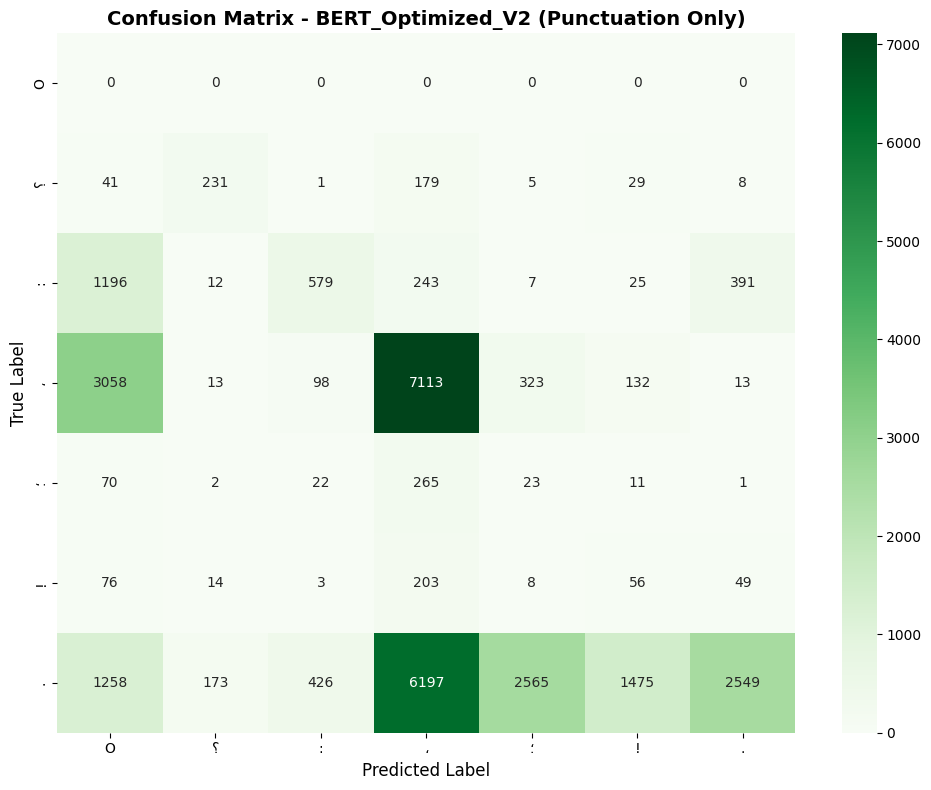


SUMMARY
Model:              BERT_Optimized_V2
Sentences tested:   4743
Total tokens:       186495
Punctuation tokens: 29143
Overall Accuracy:   85.34%
Punct Accuracy:     36.20%
F1 Weighted:        39.19%


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification
from google.colab import files, drive
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os

# ==========================================
# 1. إعداد البيئة
# ==========================================
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}\n")

# ==========================================
# 2. تحميل الموديل
# ==========================================
MODEL_PATH = "/content/drive/MyDrive/models/BERT_Optimized_V2"
MODEL_NAME = "BERT_Optimized_V2"

print(f"Loading model: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH).to(device)
print("Model loaded successfully!\n")

# ==========================================
# 3. تعريف العلامات
# ==========================================
label_to_punctuation = {0: '<PAD>', 1: 'O', 2: '؟', 3: ':', 4: '،', 5: '؛', 6: '!', 7: '.'}
punctuation_to_label = {v: k for k, v in label_to_punctuation.items()}

# ==========================================
# 4. دوال المعالجة المصححة
# ==========================================
def remove_diacritics(text):
    return re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

def is_arabic_line(text):
    return bool(re.search(r'[\u0600-\u06FF]', text))

def extract_labels_from_sentence(sentence):
    clean = remove_diacritics(sentence)

    for punct in ['،', '؛', '؟', '!', ':', '.']:
        clean = clean.replace(punct, f' {punct} ')

    tokens = [t for t in clean.split() if t.strip()]

    words = []
    labels = []

    for tok in tokens:
        if tok in punctuation_to_label:
            if labels and len(words) > 0:
                labels[-1] = punctuation_to_label[tok]
        else:
            words.append(tok)
            labels.append(1)  # O label

    return words, labels

def predict_batch(sentences, model, tokenizer):
    all_true = []
    all_pred = []

    print(f"Processing {len(sentences)} sentences...")

    for i, sentence in enumerate(sentences):
        if (i + 1) % 500 == 0:
            print(f"  Processed {i+1}/{len(sentences)}...")

        if len(sentence.split()) <= 2:
            continue

        try:
            words, true_labels = extract_labels_from_sentence(sentence)

            if not words:
                continue

            tokenized = tokenizer(
                words,
                is_split_into_words=True,
                return_tensors="pt",
                truncation=True,
                padding=True
            ).to(device)

            model.eval()
            with torch.no_grad():
                outputs = model(**tokenized)

            logits = outputs.logits
            pred_ids = logits.argmax(-1).squeeze().tolist()

            if isinstance(pred_ids, int):
                pred_ids = [pred_ids]

            word_ids = tokenized.word_ids()
            pred_labels = []
            prev_wid = None

            for idx, wid in enumerate(word_ids):
                if wid is None:
                    continue
                if wid != prev_wid and wid < len(true_labels):
                    pred_labels.append(pred_ids[idx])
                prev_wid = wid

            # مطابقة الطول
            min_len = min(len(true_labels), len(pred_labels))
            all_true.extend(true_labels[:min_len])
            all_pred.extend(pred_labels[:min_len])

        except Exception as e:
            print(f"  Error in sentence {i}: {str(e)[:100]}")
            continue

    return np.array(all_true), np.array(all_pred)

# ==========================================
# 5. رفع وقراءة الملفات
# ==========================================
print("Select text files (.txt) to upload...")
uploaded = files.upload()

if not uploaded:
    print("No files uploaded!")
    exit()

all_sentences = []
for filename in uploaded.keys():
    try:
        content = uploaded[filename].decode('utf-8')
    except:
        content = uploaded[filename].decode('cp1256', errors='ignore')

    file_lines = [line.strip() for line in content.split('\n')
                  if line.strip() and is_arabic_line(line)]
    all_sentences.extend(file_lines)

print(f"\nTotal sentences found: {len(all_sentences)}")

limit_input = input(f"How many sentences to test? (Enter for ALL): ")
if limit_input.strip():
    try:
        limit = int(limit_input)
        selected_sentences = all_sentences[:limit]
    except:
        selected_sentences = all_sentences
else:
    selected_sentences = all_sentences

print(f"\nEvaluating {len(selected_sentences)} sentences...\n")

# ==========================================
# 6. التقييم
# ==========================================
y_true, y_pred = predict_batch(selected_sentences, model, tokenizer)

# ==========================================
# 7. النتائج النهائية
# ==========================================
print("\n" + "="*70)
print("EVALUATION RESULTS")
print("="*70)

overall_acc = accuracy_score(y_true, y_pred)
print(f"\nOverall Token Accuracy: {overall_acc*100:.2f}%")

f1_macro_all = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted_all = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"F1 Macro (All):      {f1_macro_all*100:.2f}%")
print(f"F1 Weighted (All):   {f1_weighted_all*100:.2f}%")

# ==========================================
# 8. تقرير شامل (كل العلامات)
# ==========================================
print("\n" + "="*70)
print("CLASSIFICATION REPORT (All Labels)")
print("="*70)

all_labels = sorted(set(y_true) | set(y_pred))
all_names = [label_to_punctuation[i] for i in all_labels]

print(classification_report(
    y_true, y_pred,
    labels=all_labels,
    target_names=all_names,
    digits=4,
    zero_division=0
))

# ==========================================
# 9. تقرير علامات الترقيم فقط (الصحيح!)
# ==========================================
print("\n" + "="*70)
print("PUNCTUATION-ONLY METRICS")
print("="*70)

punct_mask = y_true > 1  # فقط True Punctuation
punct_true = y_true[punct_mask]
punct_pred = y_pred[punct_mask]

if len(punct_true) > 0:
    punct_acc = accuracy_score(punct_true, punct_pred)
    f1_macro_punct = f1_score(punct_true, punct_pred, average='macro', zero_division=0)
    f1_weighted_punct = f1_score(punct_true, punct_pred, average='weighted', zero_division=0)

    print(f"\nPunctuation Accuracy:  {punct_acc*100:.2f}%")
    print(f"F1 Macro (Punct):      {f1_macro_punct*100:.2f}%")
    print(f"F1 Weighted (Punct):   {f1_weighted_punct*100:.2f}%")

    print(f"\n--- Classification Report (True Punctuation Only) ---")

    punct_labels = sorted(set(punct_true) | set(punct_pred))
    punct_names = [label_to_punctuation[i] for i in punct_labels]

    print(classification_report(
        punct_true, punct_pred,
        labels=punct_labels,
        target_names=punct_names,
        digits=4,
        zero_division=0
    ))

    print("\n--- Confusion Matrix (Punctuation Only) ---")
    cm = confusion_matrix(punct_true, punct_pred, labels=punct_labels)

    cm_df = pd.DataFrame(
        cm,
        index=[f"True: {label_to_punctuation[i]}" for i in punct_labels],
        columns=[f"Pred: {label_to_punctuation[i]}" for i in punct_labels]
    )
    print(cm_df)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=punct_names, yticklabels=punct_names)
    plt.title(f'Confusion Matrix - {MODEL_NAME} (Punctuation Only)',
              fontsize=14, weight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    print("\nWARNING: No punctuation marks found in the data!")

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Model:              {MODEL_NAME}")
print(f"Sentences tested:   {len(selected_sentences)}")
print(f"Total tokens:       {len(y_true)}")
print(f"Punctuation tokens: {len(punct_true)}")
print(f"Overall Accuracy:   {overall_acc*100:.2f}%")
if len(punct_true) > 0:
    print(f"Punct Accuracy:     {punct_acc*100:.2f}%")
    print(f"F1 Weighted:        {f1_weighted_punct*100:.2f}%")
print("="*70)